In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

In [2]:
df = pd.read_csv('./Data/proccess_df.csv')
df.head()

,Product Name,Category,Dosage Form,Price,Trademark,Brand Origin,Country,Rating,Continent,General_function
0,"Gel chấm mụn, mờ thâm Decumar Advance THC 20g ...",Chăm sóc cơ thể,Gel,105000.0,DECUMAR,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
1,Dung dịch vệ sinh vùng kín Bimunica 250ml dành...,Chăm sóc cơ thể,Dạng kem,230000.0,Eucerin,Hoa Kỳ,Liên Bang Nga,5.0,Europe,Chăm sóc cơ thể
2,"Kem giảm thâm vùng nách, mông, bikini Neothera...",Chăm sóc cơ thể,Dạng kem,139000.0,La Beauty,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
3,Gel rửa mặt SVR Sebiaclear Gel Moussant 200ml ...,Chăm sóc cơ thể,Dạng kem,390000.0,SVR,Pháp,Pháp,unknown,Europe,Chăm sóc cơ thể
4,Bọt vệ sinh nam giới Sumely Men's Sanitary Foa...,"Lăn khử mùi, xịt khử mùi",Dạng bọt,96000.0,Eucerin,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể


In [3]:
pd.set_option('display.max_rows', None)  # Hiển thị tất cả các dòng
pd.set_option('display.max_columns', None)  # Hiển thị tất cả các cột
pd.set_option('display.max_colwidth', None)  # Hiển thị đầy đủ độ rộng của cột

In [4]:
df.isnull().sum()

Product Name        0
Category            0
Dosage Form         0
Price               0
Trademark           0
Brand Origin        0
Country             0
Rating              0
Continent           0
General_function    0
dtype: int64

In [5]:
df['Rating'].value_counts()

Rating
5.0        990
unknown    779
4.9         60
4.8         46
4.7         31
4.6         24
4.5         20
4.0         16
3.0          7
4.4          5
1.0          5
4.2          5
4.3          5
3.6          2
2.0          2
4.1          1
3.5          1
Name: count, dtype: int64

In [6]:
df['Continent'].value_counts()

Continent
Asia       1215
Europe      439
America     228
Other       113
Africa        4
Name: count, dtype: int64

In [7]:
df['Country'].value_counts()

Country
Việt Nam                     897
Hoa Kỳ                       194
Nhật Bản                     130
Pháp                         127
Úc                           101
Đức                           75
Hàn Quốc                      60
Ý                             58
Ba Lan                        43
Thái Lan                      37
Ấn Độ                         35
Canada                        28
Singapore                     24
Anh                           19
Tây Ban Nha                   17
Hà Lan                        16
Thụy Điển                     15
Bulgaria                      13
New Zealand                   12
Thụy Sĩ                       11
Đan Mạch                      11
Indonesia                     10
Malaysia                       9
Slovenia                       7
Thổ Nhĩ Kỳ                     7
Brasil                         5
Monaco                         4
Trung Quốc                     4
Nam Phi                        3
Na Uy                          3
TA

In [8]:
df['Brand Origin'].value_counts()

Brand Origin
Việt Nam       908
Hoa Kỳ         222
Nhật Bản       155
Pháp           128
Úc              98
Đức             91
Hàn Quốc        52
Ý               51
Ba Lan          34
Mỹ              34
Anh             27
Thụy Sĩ         25
Canada          22
Thái Lan        19
Thụy Điển       16
Singapore       15
New Zealand     15
Hà Lan          12
Tây Ban Nha     12
Ấn Độ           10
Thổ Nhĩ Kỳ       7
Đan Mạch         6
Bulgaria         5
Malaysia         5
Indonesia        4
Slovenia         4
Na Uy            3
Hồng Kông        3
Hungary          2
Hy Lạp           2
Iran             2
Nam Phi          2
Đài Loan         2
Trung Quốc       1
Slovakia         1
Áo               1
Bangladesh       1
Latvia           1
Phần Lan         1
Name: count, dtype: int64

In [9]:
df['Brand Origin'] = df['Brand Origin'].replace({'Hoa Kỳ': 'Mỹ'})
df['Country'] = df['Country'].replace({'Hoa Kỳ': 'Mỹ', 'USA': 'Mỹ'})

# VISUALIZATION

In [10]:
rating_df = df[df['Rating'] != 'unknown']
rating_df

,Product Name,Category,Dosage Form,Price,Trademark,Brand Origin,Country,Rating,Continent,General_function
0,"Gel chấm mụn, mờ thâm Decumar Advance THC 20g dưỡng ẩm da, da mềm, mịn",Chăm sóc cơ thể,Gel,105000.0,DECUMAR,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
1,Dung dịch vệ sinh vùng kín Bimunica 250ml dành cho bé gái từ 0 tháng tuổi,Chăm sóc cơ thể,Dạng kem,230000.0,Eucerin,Mỹ,Liên Bang Nga,5.0,Europe,Chăm sóc cơ thể
2,"Kem giảm thâm vùng nách, mông, bikini Neothera Armpit Cream La Beaute 35ml dưỡng trắng da",Chăm sóc cơ thể,Dạng kem,139000.0,La Beauty,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
4,"Bọt vệ sinh nam giới Sumely Men's Sanitary Foam giúp làm sạch, khử và ngăn chặn mùi vùng kín (100ml)","Lăn khử mùi, xịt khử mùi",Dạng bọt,96000.0,Eucerin,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
5,Sữa rửa mặt On: The Body Rice Therapy Heartleaf Acne Cleanser làm sạch sâu không gây khô da (150ml),"Sữa rửa mặt (Kem, gel, sữa)",Dạng kem,132000.0,Eucerin,Hàn Quốc,Hàn Quốc,5.0,Asia,Chăm sóc da mặt
6,"Nước tẩy trang JMsolution Water Luminous S.O.S Ringer Cleansing Water giúp làm sạch bụi bẩn, dầu thừa và lớp trang điểm (500ml)","Nước tẩy trang, dầu tẩy trang",Dạng kem,199000.0,Eucerin,Hàn Quốc,Hàn Quốc,5.0,Asia,Chăm sóc da mặt
7,Gel Rosette Gommage Clear Peel tẩy tế bào chết (180g),Tẩy tế bào chết,Gel,185000.0,Rosette,Nhật Bản,Nhật Bản,5.0,Asia,Hỗ trợ làm đẹp
8,"Gel làm mờ sẹo Fixderma Scars do mụn, bỏng, rạn da, vết thươngl (7ml)","Trị sẹo, mờ vết thâm",Dạng kem,132800.0,Fixderma,Mỹ,Ấn Độ,5.0,Asia,Hỗ trợ làm đẹp
9,Gội phủ bạc Healthy and lively H4 Lavox màu nâu cà phê (10 gói x 30ml),Dầu gội dầu xả,Dung dịch,22400.0,LAVOX,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc tóc - da đầu
11,Sữa tắm giảm mụn lưng Neo Acnes tinh chất tràm trà (250ml),"Sữa tắm, xà bông",Dung dịch,143200.0,Neo Acnes,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể


In [11]:
unrating_df = df[df['Rating'] == 'unknown']
unrating_df

,Product Name,Category,Dosage Form,Price,Trademark,Brand Origin,Country,Rating,Continent,General_function
3,Gel rửa mặt SVR Sebiaclear Gel Moussant 200ml làm sạch không chứa xà phòng và loại bỏ tế bào da chết,Chăm sóc cơ thể,Dạng kem,390000.0,SVR,Pháp,Pháp,unknown,Europe,Chăm sóc cơ thể
10,Gội phủ bạc Healthy and lively H1 Lavox màu đen (10 gói x 30ml),Dầu gội dầu xả,Dung dịch,22400.0,LAVOX,Việt Nam,Việt Nam,unknown,Asia,Chăm sóc tóc - da đầu
14,Sữa chống nắng dưỡng ẩm kiềm dầu NeoAqua Sunscreen Expert Milk SPF50+ (30ml),Chống nắng toàn thân,Dạng kem,151200.0,NeoAqua,Việt Nam,Việt Nam,unknown,Asia,Chăm sóc cơ thể
30,"Dầu gió lăn Red Lion Medicated Oil Yellow Agimexpharm ấm da vùng xoa, sử dụng massage hỗ trợ thư giãn (10ml)",Chăm sóc cơ thể,Dạng kem,39000.0,Agimexpharm,Việt Nam,Việt Nam,unknown,Asia,Chăm sóc cơ thể
31,"Dầu gió lăn Red Lion Medicated Oil White Agimexpharm ấm da vùng xoa, sử dụng massage hỗ trợ thư giãn (10ml)",Chăm sóc cơ thể,Dạng kem,39000.0,Agimexpharm,Việt Nam,Việt Nam,unknown,Asia,Chăm sóc cơ thể
60,"Xịt PanSpray Panthenol hỗ trợ giảm đau, rát, hạn chế tổn thương, viêm nhiễm da (130g)",Trị nứt da,Dạng xịt,155000.0,Panthenol,Việt Nam,Việt Nam,unknown,Asia,Hỗ trợ làm đẹp
64,"Tinh dầu tràm ngâm củ nén Mệ Đoan phòng và điều trị cảm cúm, trúng gió, ho, ngạt mũi, long đờm (50ml)",Tinh dầu,Dạng kem,185000.0,Mệ Đoan,Việt Nam,Việt Nam,unknown,Asia,Sản phẩm từ thiên nhiên
65,"Mặt nạ Marine Luminous Pearl Deep Moisture Mask Peal JMsolution tăng cường dưỡng ẩm, dưỡng trắng (30ml)",Mặt nạ,Dạng kem,22400.0,Eucerin,Hàn Quốc,Hàn Quốc,unknown,Asia,Chăm sóc da mặt
66,Gel nhuộm tóc phủ bạc Flash Lavox G01 màu đen (150ml),Dầu gội dầu xả,Gel,158000.0,LAVOX,Việt Nam,Việt Nam,unknown,Asia,Chăm sóc tóc - da đầu
71,Kem dưỡng ẩm mềm mịn và chống nhăn da tay Reihaku Hatomugi Hand Cream (65g),"Kem dưỡng da tay, chân",Dạng kem,70000.0,HATOMUGI,Nhật Bản,Nhật Bản,unknown,Asia,Chăm sóc cơ thể


## Tần suất xuất hiện của từng chức năng của sản phẩm được quan tâm và không quan tâm

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\4191264466.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\4191264466.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(unrating_counts_sorted.index, rotation=90)


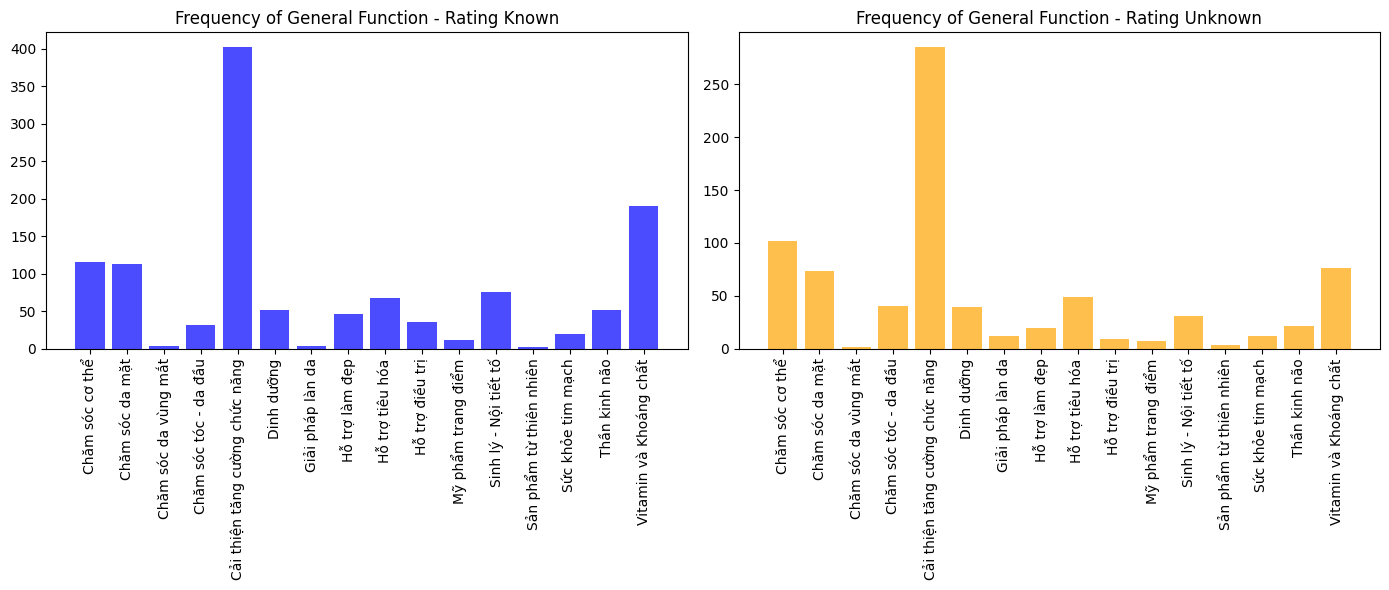

In [12]:
rating_counts = rating_df['General_function'].value_counts()
unrating_counts = unrating_df['General_function'].value_counts()


common_index = rating_counts.index.union(unrating_counts.index)

rating_counts_sorted = rating_counts.reindex(common_index, fill_value=0)
unrating_counts_sorted = unrating_counts.reindex(common_index, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the rating data frequency
axes[0].bar(rating_counts_sorted.index, rating_counts_sorted.values, color='blue', alpha=0.7)
axes[0].set_title('Frequency of General Function - Rating Known')
axes[0].set_xticklabels(rating_counts_sorted.index, rotation=90)

# Plot the unrating data frequency
axes[1].bar(unrating_counts_sorted.index, unrating_counts_sorted.values, color='orange', alpha=0.7)
axes[1].set_title('Frequency of General Function - Rating Unknown')
axes[1].set_xticklabels(unrating_counts_sorted.index, rotation=90)

plt.tight_layout()
plt.show()


## Ở mỗi chức năng, tần suất xuất hiện của các quốc gia xuất xứ ở sản phẩm được quan tâm và không được quan tâm

In [13]:
def frequence_countries_by_general_function(func: str):
    func_rating_df = rating_df[rating_df['General_function'] == func]
    func_unrating_df = unrating_df[unrating_df['General_function'] == func]

    func_rating_counts = func_rating_df['Brand Origin'].value_counts()
    func_unrating_counts = func_unrating_df['Brand Origin'].value_counts()

    # Xác định các chỉ mục chung giữa các cột
    common_index = func_rating_counts.index.union(func_unrating_counts.index)

    # Đảm bảo các cột có cùng thứ tự và bổ sung giá trị 0 nếu thiếu
    func_rating_counts_sorted = func_rating_counts.reindex(common_index, fill_value=0)
    func_unrating_counts_sorted = func_unrating_counts.reindex(common_index, fill_value=0)

    # Xác định giá trị y lớn nhất
    max_y = max(func_rating_counts_sorted.max(), func_unrating_counts_sorted.max()) * 1.1

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Biểu đồ cho Rating Known
    axes[0].bar(func_rating_counts_sorted.index, func_rating_counts_sorted.values, color='blue', alpha=0.7)
    axes[0].set_title(f'Frequency of Brand Origin - Rating Known ({func})')
    axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
    axes[0].yaxis.get_major_locator().set_params(integer=True)
    axes[0].set_ylim(0, max_y)
    axes[0].set_xlabel('Brand Origin')
    axes[0].set_ylabel('Frequency')

    # Biểu đồ cho Rating Unknown
    axes[1].bar(func_unrating_counts_sorted.index, func_unrating_counts_sorted.values, color='orange', alpha=0.7)
    axes[1].set_title(f'Frequency of Brand Origin - Rating Unknown ({func})')
    axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)
    axes[1].yaxis.get_major_locator().set_params(integer=True)
    axes[1].set_ylim(0, max_y)
    axes[1].set_xlabel('Brand Origin')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [14]:
unique_func = df['General_function'].unique()
unique_func

array(['Chăm sóc cơ thể', 'Chăm sóc da mặt', 'Hỗ trợ làm đẹp',
       'Chăm sóc tóc - da đầu', 'Giải pháp làn da', 'Mỹ phẩm trang điểm',
       'Sản phẩm từ thiên nhiên', 'Chăm sóc da vùng mắt',
       'Cải thiện tăng cường chức năng', 'Vitamin và Khoáng chất',
       'Thần kinh não', 'Hỗ trợ tiêu hóa', 'Sinh lý - Nội tiết tố',
       'Hỗ trợ điều trị', 'Sức khỏe tim mạch', 'Dinh dưỡng'], dtype=object)

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


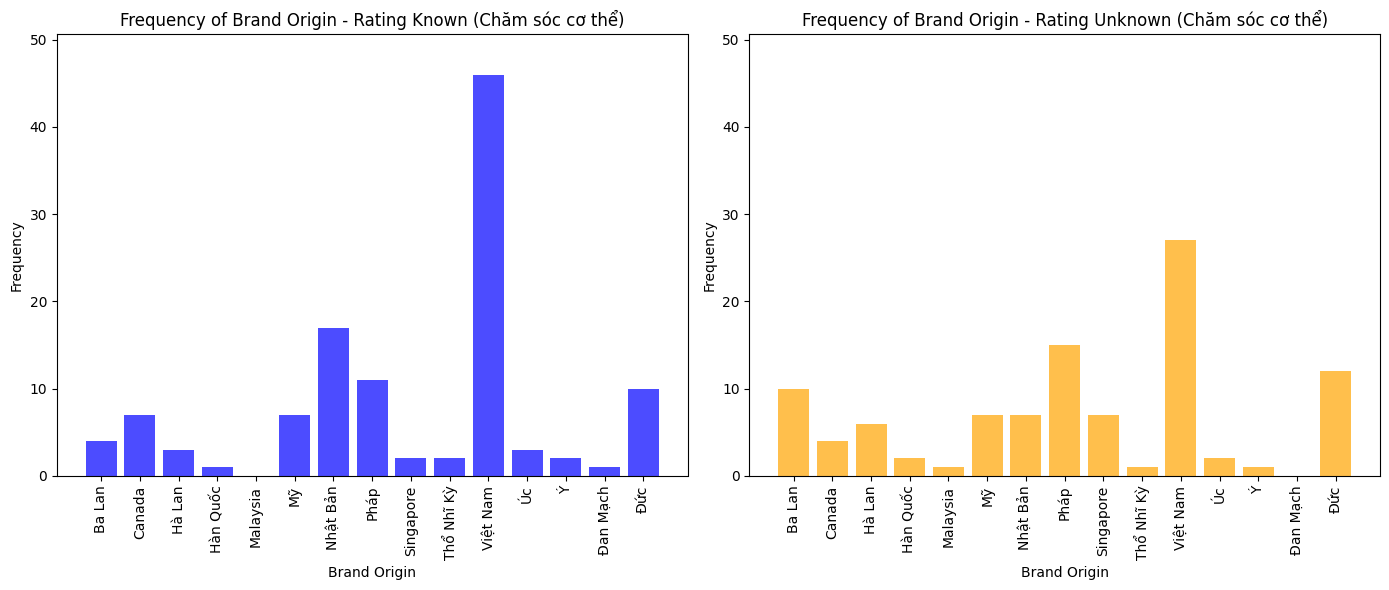

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


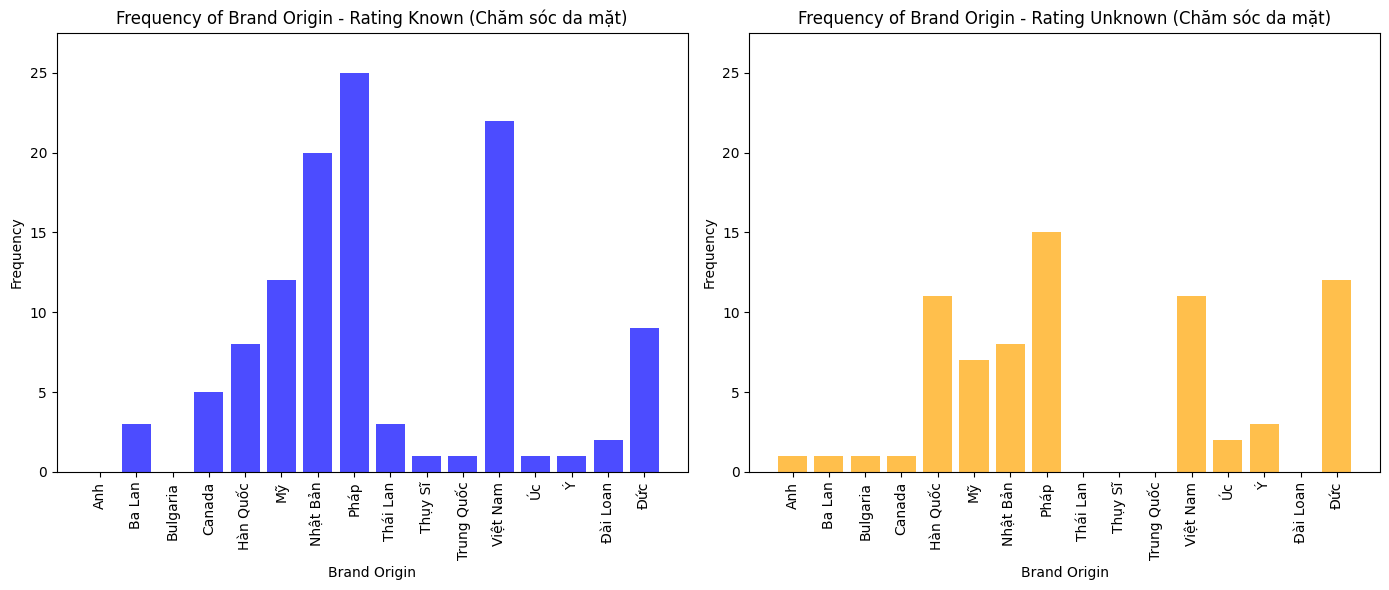

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


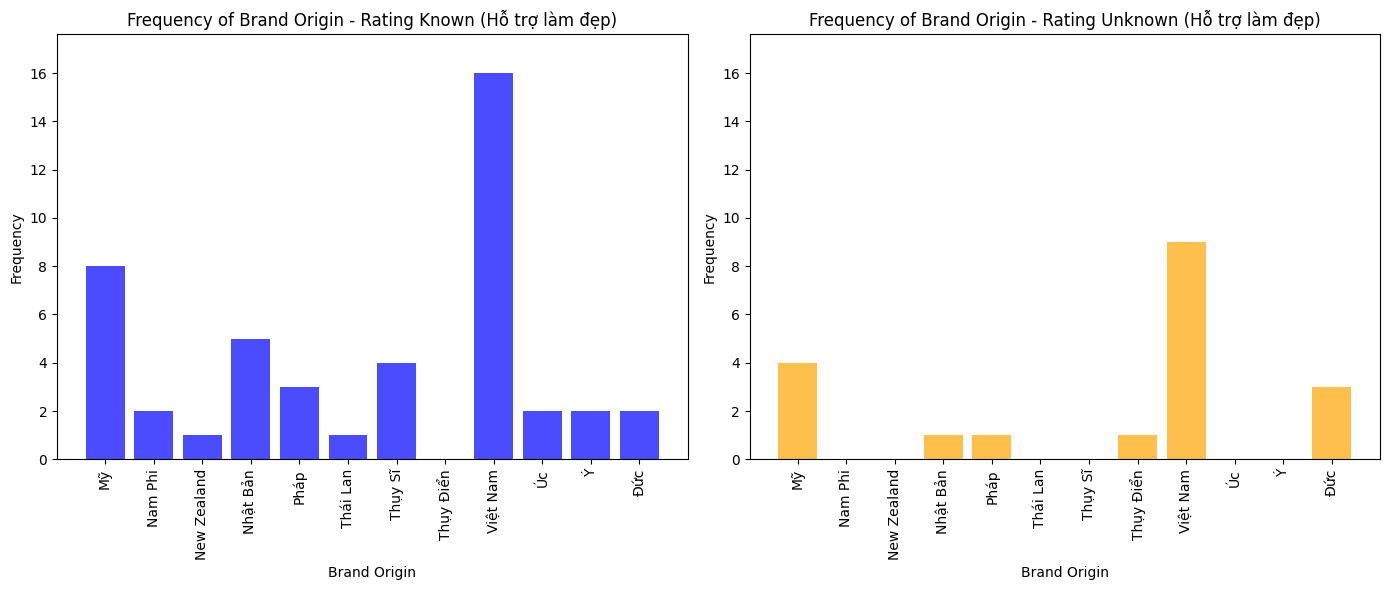

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


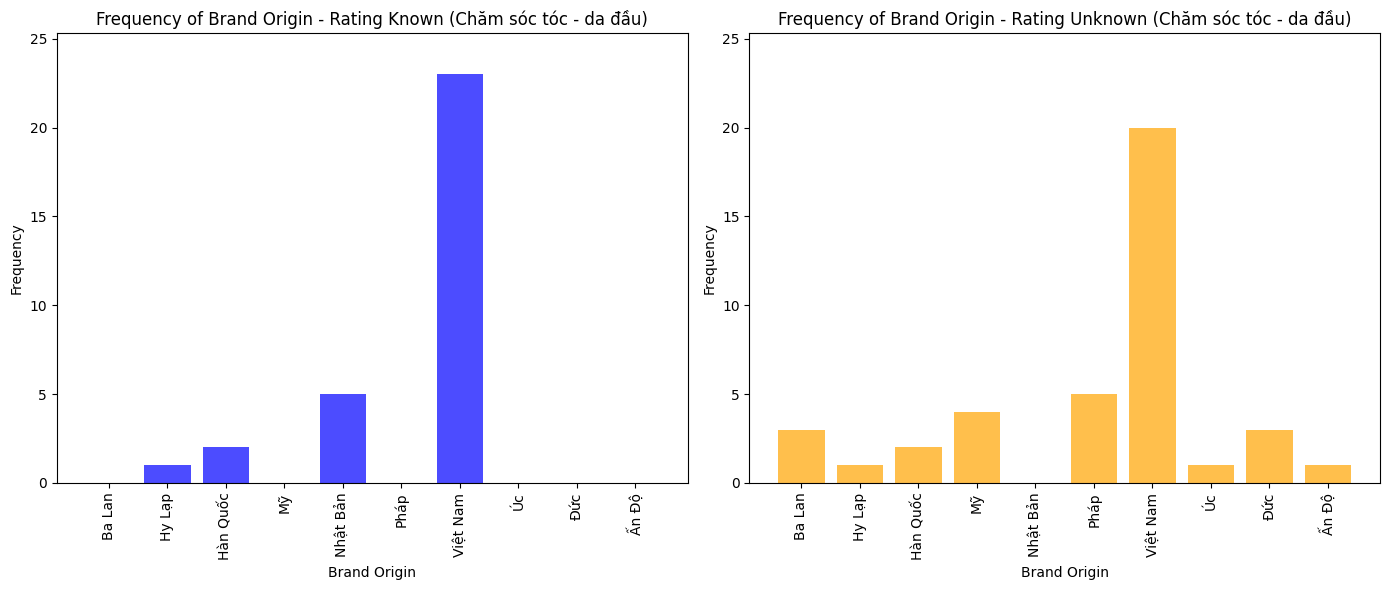

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


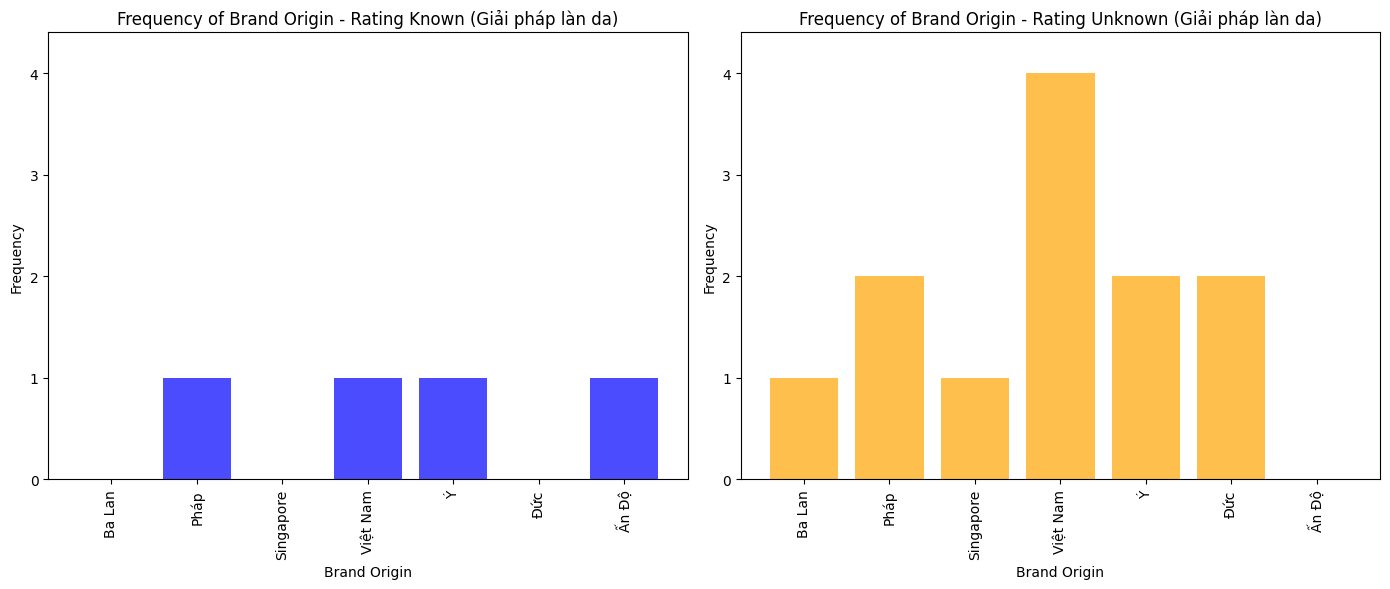

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


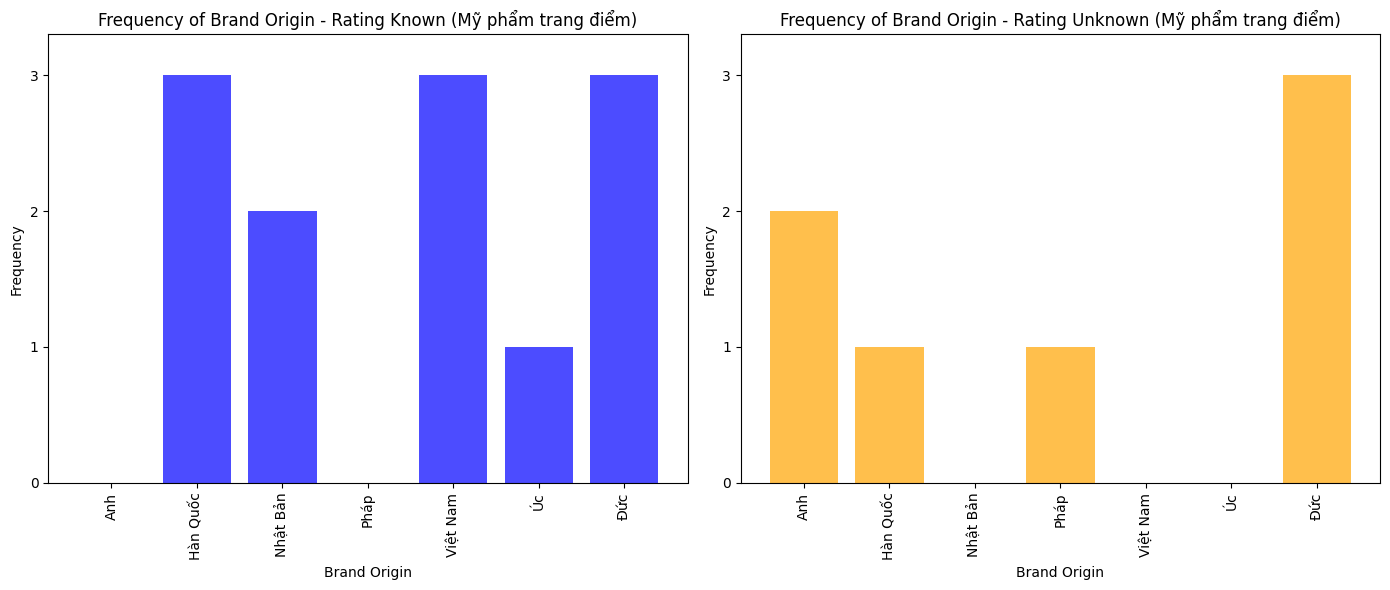

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


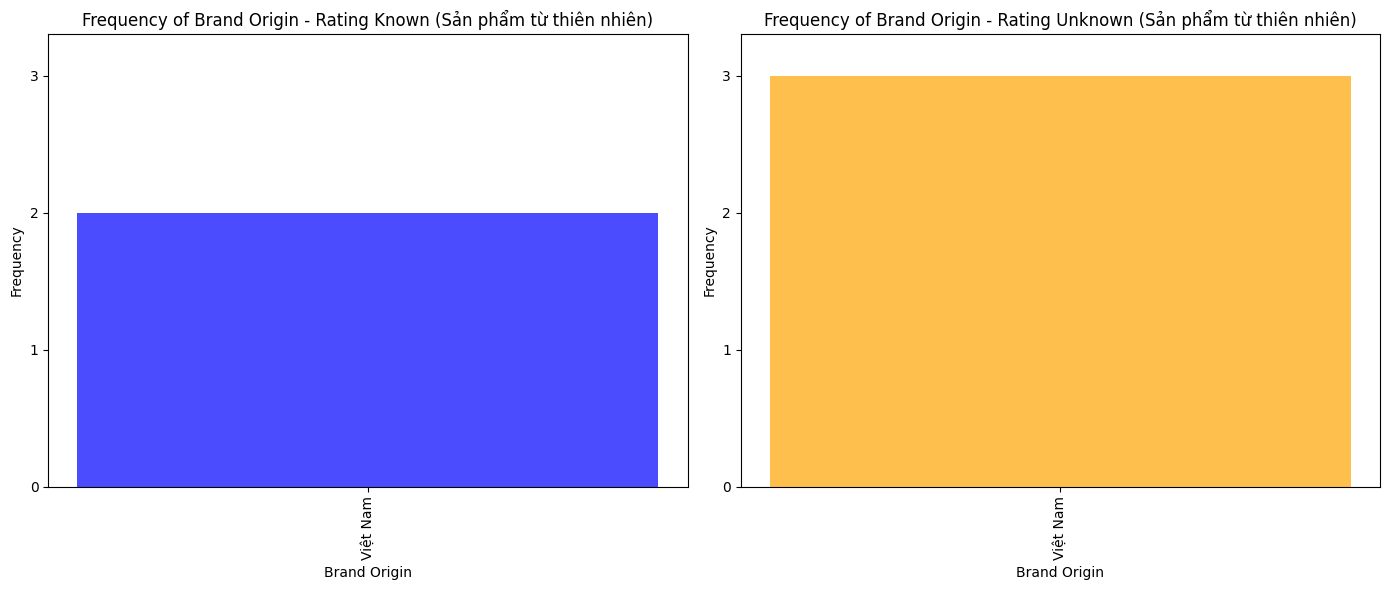

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


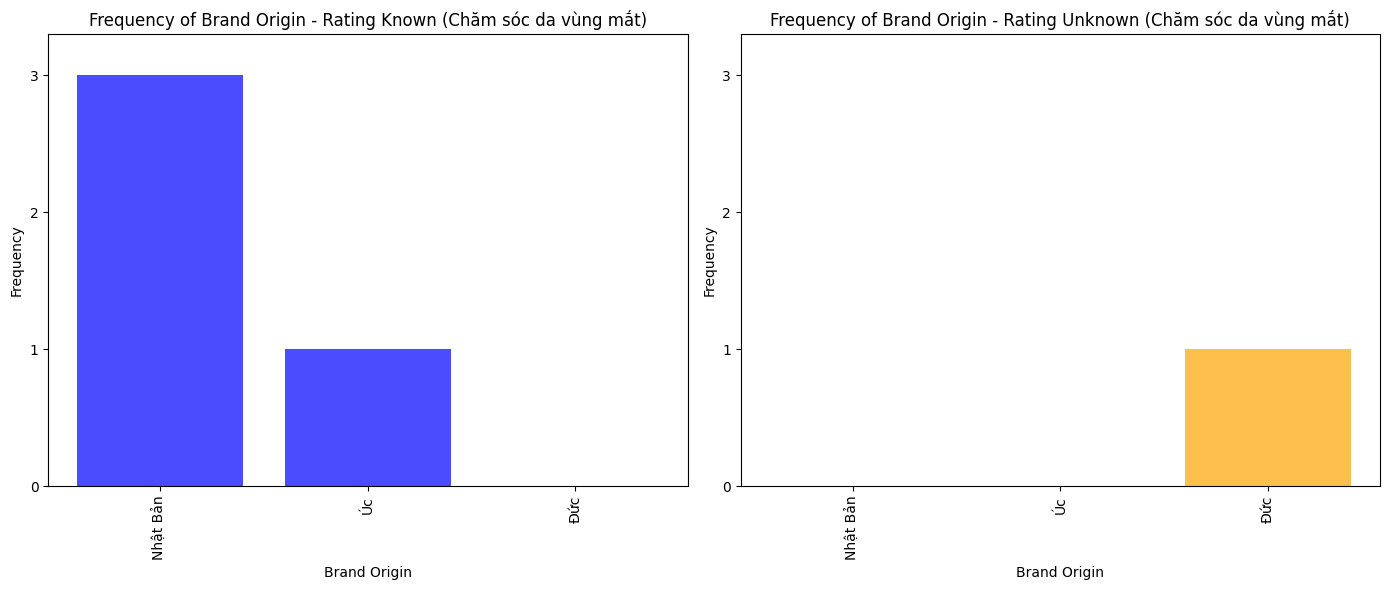

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


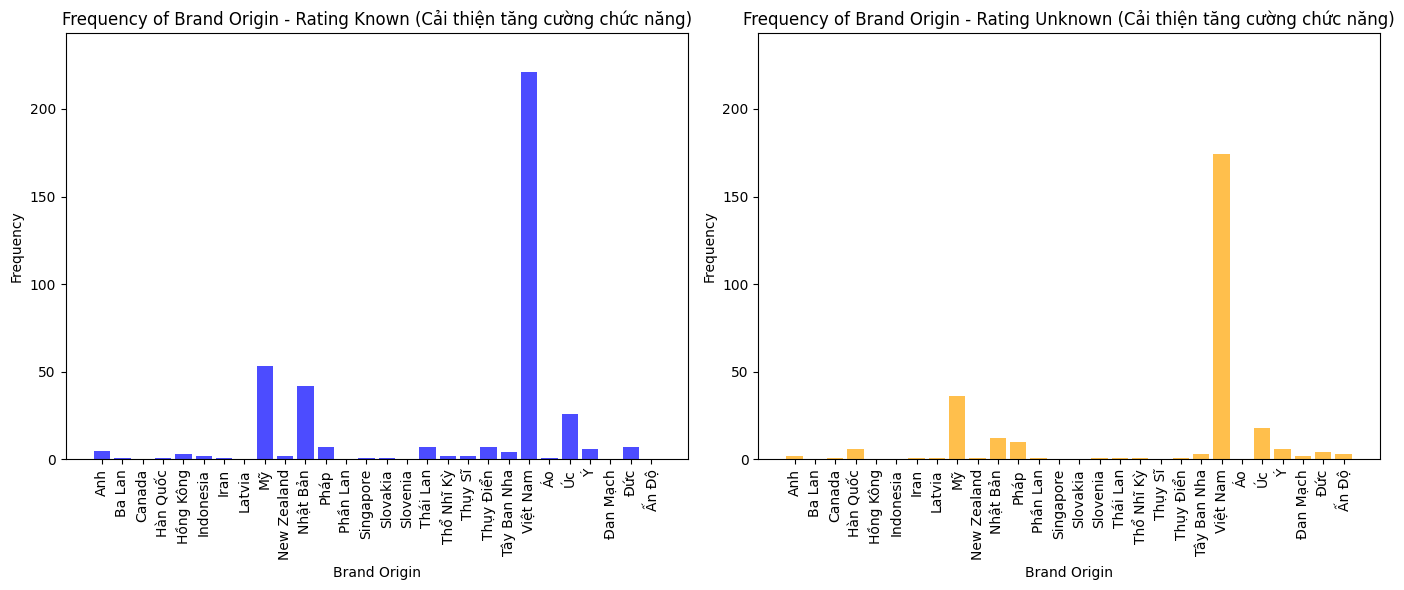

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


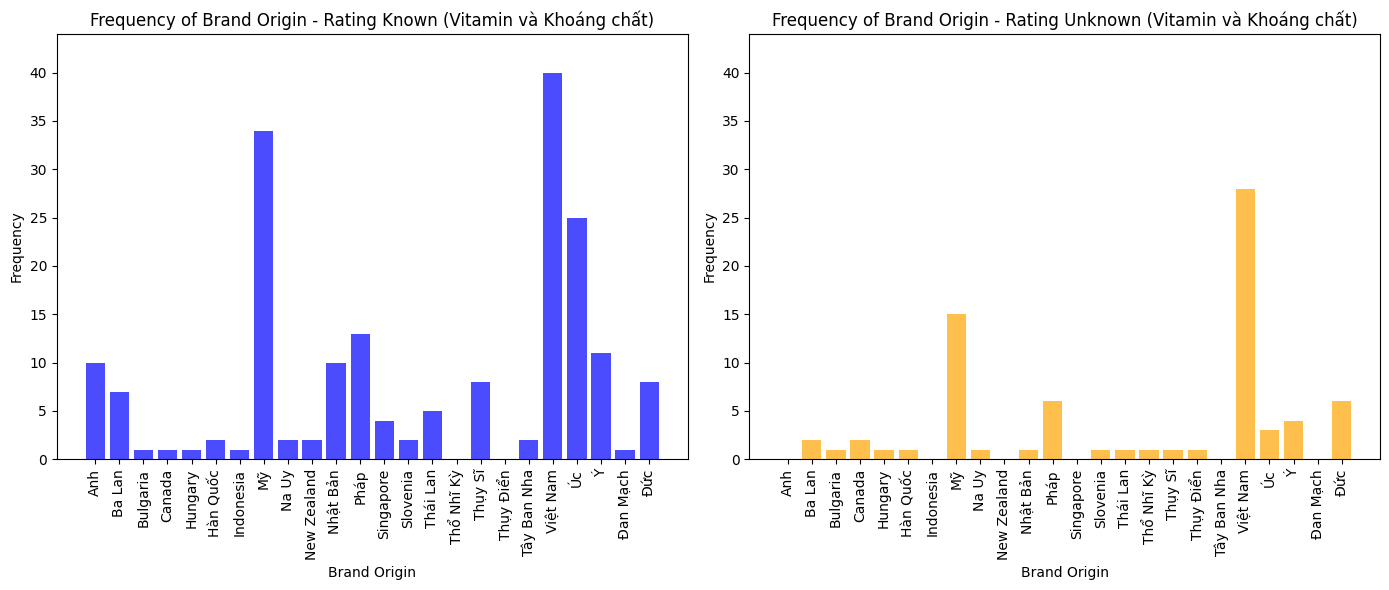

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


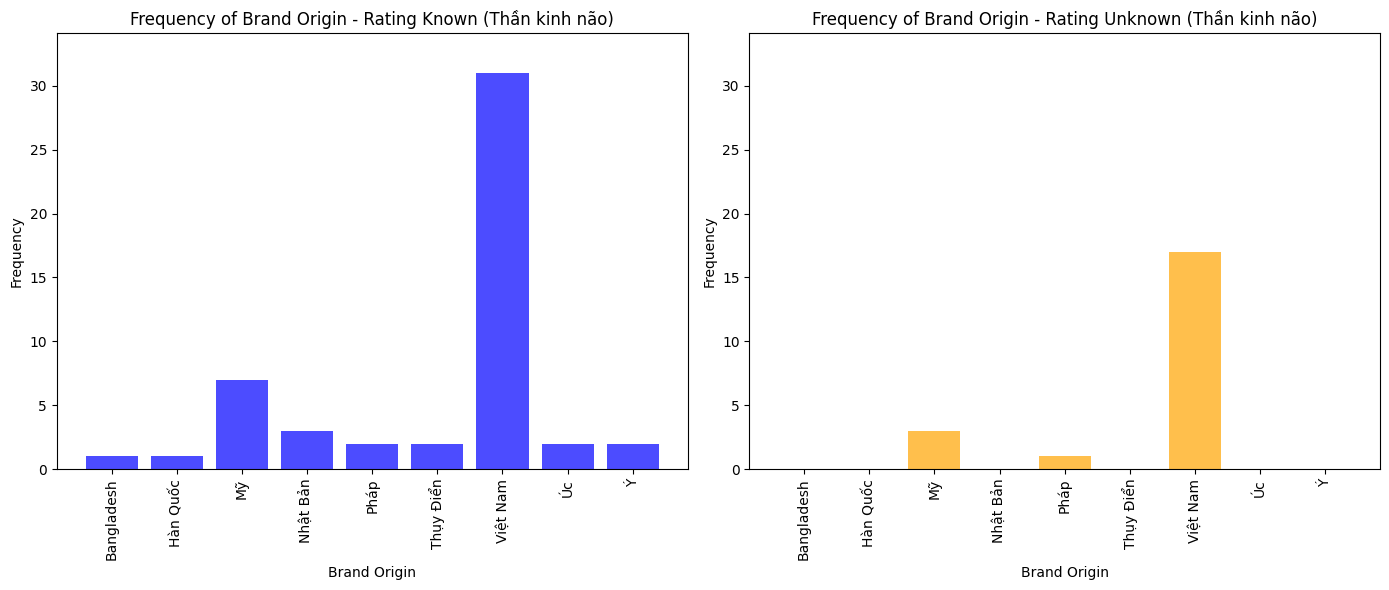

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


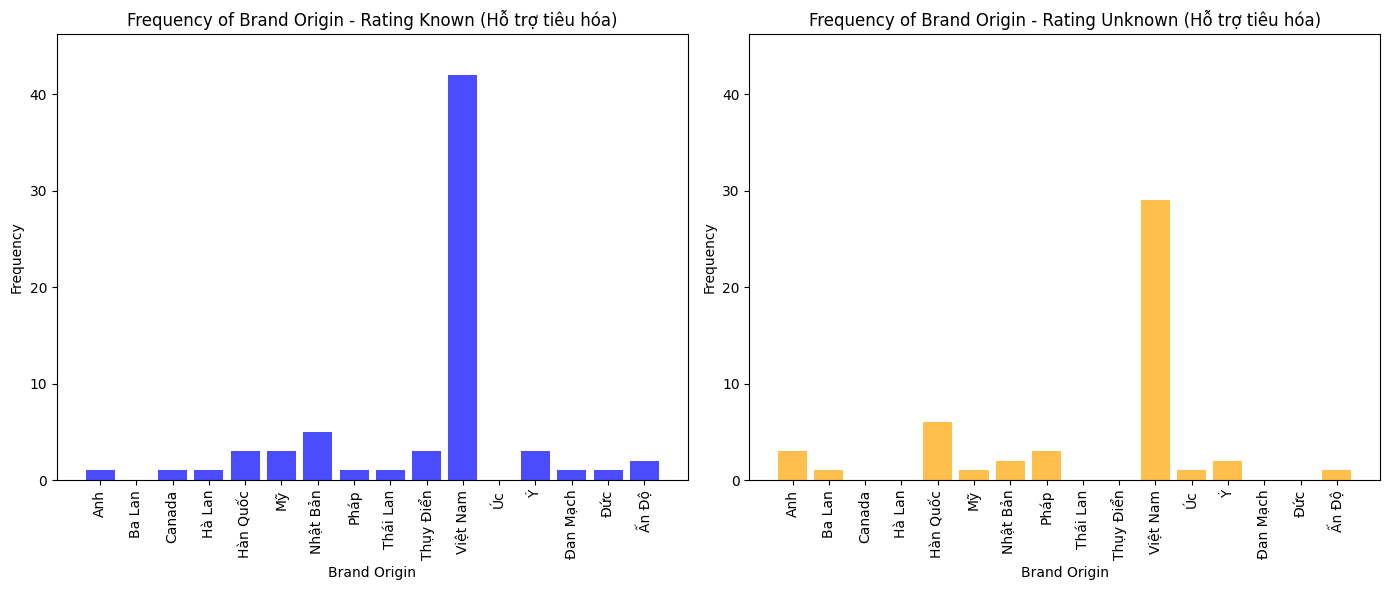

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


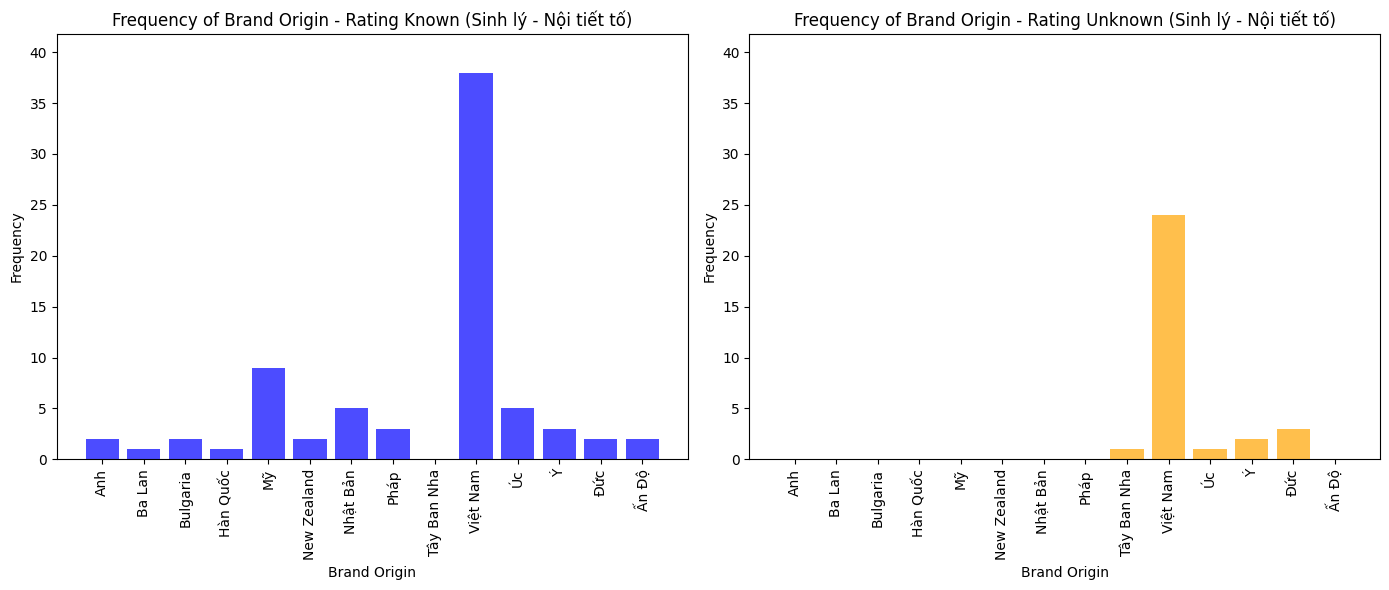

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


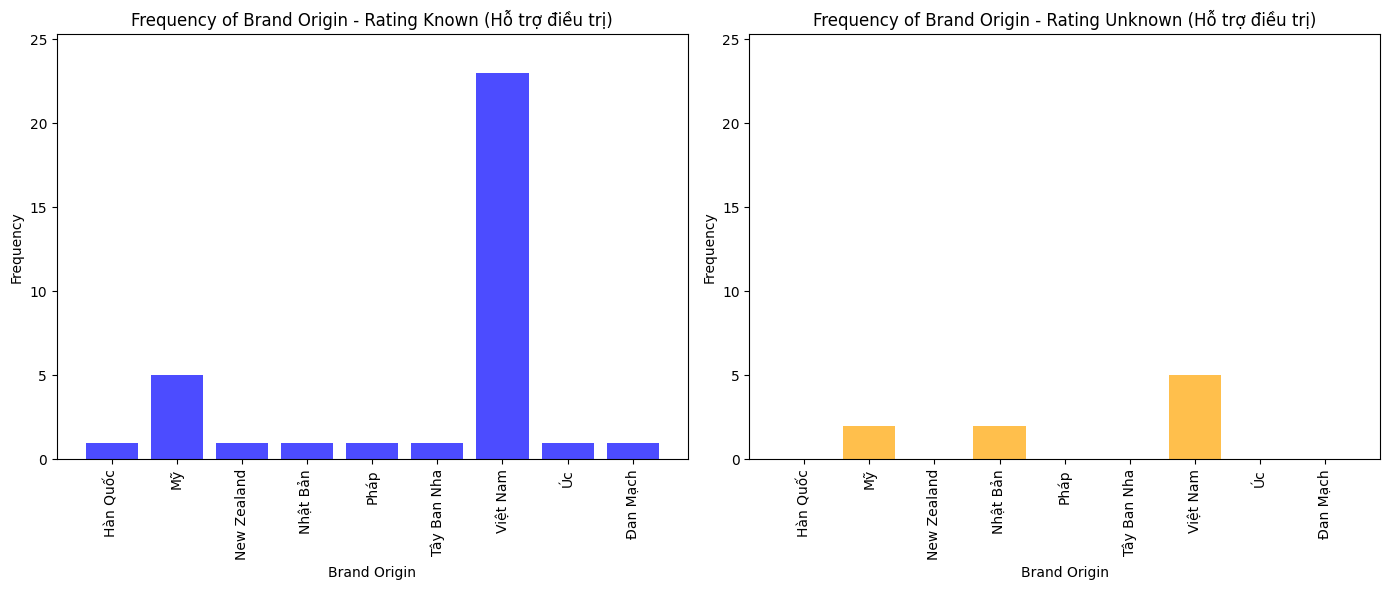

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


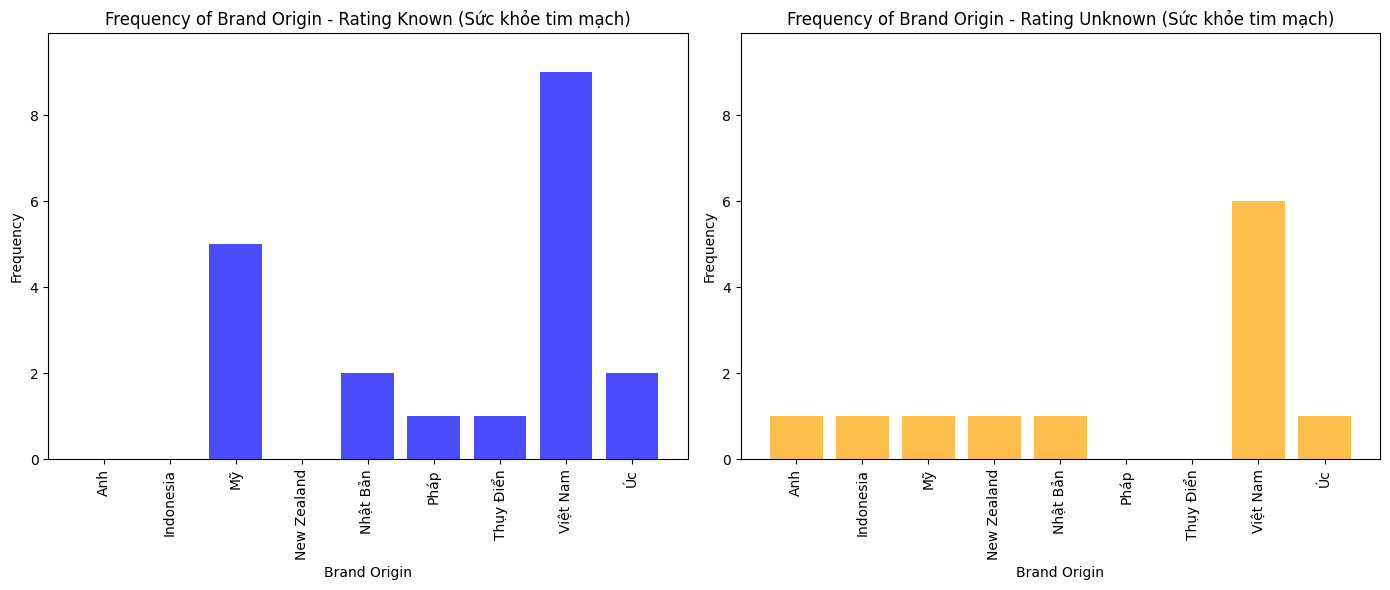

C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(func_rating_counts_sorted.index, rotation=90)
C:\Users\admin\AppData\Local\Temp\ipykernel_18708\2270068782.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(func_unrating_counts_sorted.index, rotation=90)


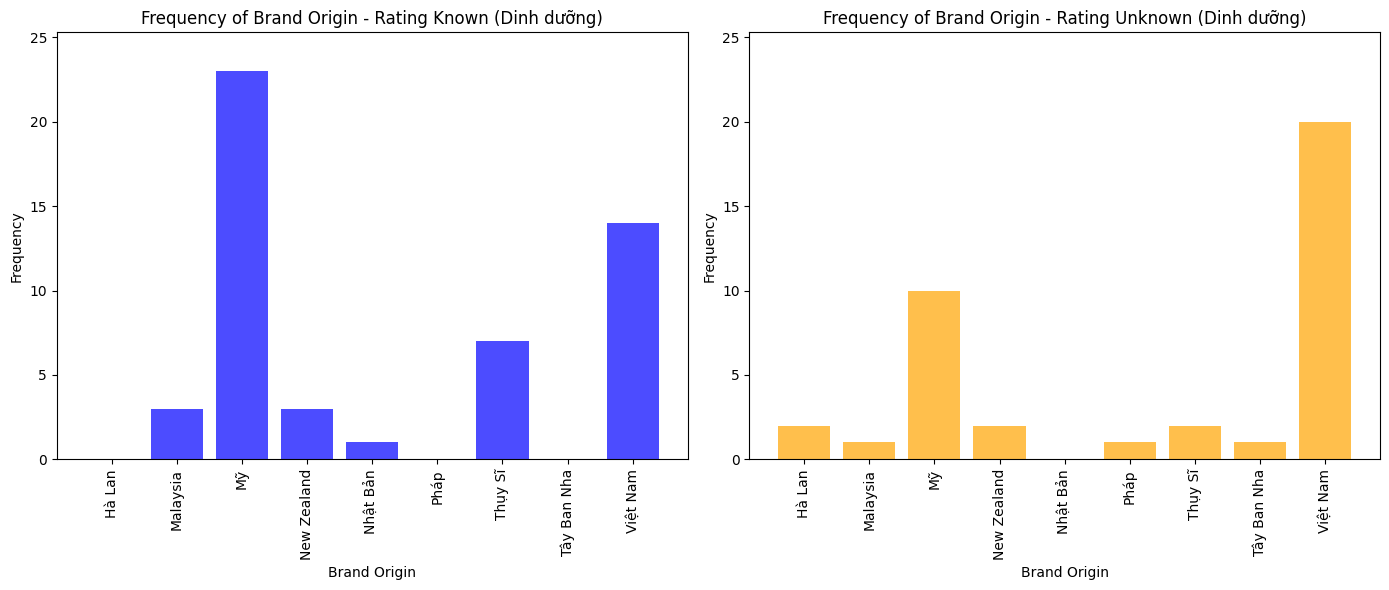

In [15]:
for func in unique_func:
    frequence_countries_by_general_function(func)

- Ở các mục "Chăm sóc cơ thể', "Chăm sóc da mặt", "Hỗ trợ làm đẹp", "Mỹ phẩm trang điểm", "Cải thiện tăng cường chức năng", "Vitamin và khoáng chất", "Thân kinh não", "Hỗ trợ tiêu hóa", "Sinh lý - Nội tiết tố", "Hỗ trợ điều trị", "Sức khỏe tim mạch", "Dinh dưỡng"

- Ở mục "Chăm sóc tóc - da đầu", sản phẩm có nguồn gốc từ Pháp, Mỹ, Đức không được dùng quan tâm nhiều

- Các sản phẩm từ mục "Giải pháp làn da", "Sản phẩm từ thiên nhiên", "Chăm sóc da vùng mắt" có vẻ được người dùng không được quan tâm nhiều vì số lượng sản phẩm xuất hiện không được nhiều.

- Ở "Thần kinh não", tuy sản phẩm ở danh mục này có nguồn gốc từ Nhật Bản, Ý, Úc, Thụy Điển, Hàn Quốc, Bangladesh tuy nhỏ, nhưng lại được quan tâm toàn bộ.

- Ở "Sinh lý - Nội tiết tố", sản phẩm có nguồn gốc từ Tây Ban Nha không được quan tâm.

- "Chăm sóc da mặt" có xuất xứ từ Pháp được quan tâm hơn hẳn.

- "Sức khỏe tim mạch", sản phẩm có nguồn gốc từ Anh, Indonesia, New Zealand không được quan tâm, trong khi đó, những sản phẩm có nguồn gốc từ Pháp, Thủy Điển lại được quan tâm hơn.

=> Nguồn gốc xuất xứ không ảnh hưởng quá nhiều tới quyết định người mua

In [16]:
def top3_origin_countries_by_general_function(func: str, data: pd.DataFrame):
    # Lọc dữ liệu rating theo 'General_function'
    func_rating_df = data[data['General_function'] == func]

    # Tính số lần xuất hiện của mỗi quốc gia
    func_rating_counts = func_rating_df['Brand Origin'].value_counts()

    # Trả về tên các quốc gia có số lượng lớn nhất (top 3)
    top_3_countries = func_rating_counts.head(3).index.tolist()
    
    return top_3_countries


#### Top 3 quốc gia xuất xứ được quan tâm ở mỗi sản phẩm chức năng

In [17]:
for func in unique_func:
    top_3_countries = top3_origin_countries_by_general_function(func, rating_df)
    if top_3_countries:  # Chỉ in nếu có dữ liệu top 3
        print(f"General Function: {func}")
        print(f"Top 3 Origin Countries: {', '.join(top_3_countries)}")
        print("-" * 50)
        print()


General Function: Chăm sóc cơ thể
Top 3 Origin Countries: Việt Nam, Nhật Bản, Pháp
--------------------------------------------------

General Function: Chăm sóc da mặt
Top 3 Origin Countries: Pháp, Việt Nam, Nhật Bản
--------------------------------------------------

General Function: Hỗ trợ làm đẹp
Top 3 Origin Countries: Việt Nam, Mỹ, Nhật Bản
--------------------------------------------------

General Function: Chăm sóc tóc - da đầu
Top 3 Origin Countries: Việt Nam, Nhật Bản, Hàn Quốc
--------------------------------------------------

General Function: Giải pháp làn da
Top 3 Origin Countries: Việt Nam, Ấn Độ, Ý
--------------------------------------------------

General Function: Mỹ phẩm trang điểm
Top 3 Origin Countries: Hàn Quốc, Việt Nam, Đức
--------------------------------------------------

General Function: Sản phẩm từ thiên nhiên
Top 3 Origin Countries: Việt Nam
--------------------------------------------------

General Function: Chăm sóc da vùng mắt
Top 3 Origin Countri

#### Top 3 quốc gia xuất xứ KHÔNG được quan tâm ở mỗi sản phẩm chức năng

In [18]:
for func in unique_func:
    top_3_countries = top3_origin_countries_by_general_function(func, unrating_df)
    if top_3_countries:  # Chỉ in nếu có dữ liệu top 3
        print(f"General Function: {func}")
        print(f"Top 3 Origin Countries: {', '.join(top_3_countries)}")
        print("-" * 50)
        print()


General Function: Chăm sóc cơ thể
Top 3 Origin Countries: Việt Nam, Pháp, Đức
--------------------------------------------------

General Function: Chăm sóc da mặt
Top 3 Origin Countries: Pháp, Đức, Hàn Quốc
--------------------------------------------------

General Function: Hỗ trợ làm đẹp
Top 3 Origin Countries: Việt Nam, Mỹ, Đức
--------------------------------------------------

General Function: Chăm sóc tóc - da đầu
Top 3 Origin Countries: Việt Nam, Pháp, Mỹ
--------------------------------------------------

General Function: Giải pháp làn da
Top 3 Origin Countries: Việt Nam, Pháp, Đức
--------------------------------------------------

General Function: Mỹ phẩm trang điểm
Top 3 Origin Countries: Đức, Anh, Hàn Quốc
--------------------------------------------------

General Function: Sản phẩm từ thiên nhiên
Top 3 Origin Countries: Việt Nam
--------------------------------------------------

General Function: Chăm sóc da vùng mắt
Top 3 Origin Countries: Đức
---------------------

In [19]:
def plot_price_boxplot_top3_countries(func: str):
    # Lấy top 3 quốc gia cho chức năng từ rating_df và unrating_df
    top_3_countries_rating = top3_origin_countries_by_general_function(func, rating_df)
    top_3_countries_unrating = top3_origin_countries_by_general_function(func, unrating_df)
    
    # Lọc dữ liệu rating_df cho top 3 quốc gia
    func_rating_df = rating_df[(rating_df['General_function'] == func) & (rating_df['Brand Origin'].isin(top_3_countries_rating))]
    
    # Lọc dữ liệu unrating_df cho top 3 quốc gia
    func_unrating_df = unrating_df[(unrating_df['General_function'] == func) & (unrating_df['Brand Origin'].isin(top_3_countries_unrating))]

    # Bỏ qua nếu cả hai DataFrame đều không có dữ liệu
    if func_rating_df.empty and func_unrating_df.empty:
        return

    # Tạo figure với 2 biểu đồ (subplots)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    fig.suptitle(f"Box Plot of Price for General Function: {func} (Top 3 Countries)")
    
    def format_price(x, pos):
        return f'{x:,.0f}'

    # Vẽ box plot cho rating_df
    if not func_rating_df.empty:
        sns.boxplot(ax=axes[0], x='Brand Origin', y='Price', data=func_rating_df)
        axes[0].set_title('Rating')
        axes[0].set_xlabel('Brand Country')
        axes[0].set_ylabel('Price')
        axes[0].tick_params(axis='x', rotation=90)
        axes[0].yaxis.set_major_formatter(FuncFormatter(format_price))

    # Vẽ box plot cho unrating_df
    if not func_unrating_df.empty:
        sns.boxplot(ax=axes[1], x='Brand Origin', y='Price', data=func_unrating_df, color='orange')
        axes[1].set_title('Unrating')
        axes[1].set_xlabel('Brand Origin')
        axes[1].tick_params(axis='x', rotation=90)
        axes[1].yaxis.set_major_formatter(FuncFormatter(format_price))

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Để lại không gian cho tiêu đề chính
    plt.show()


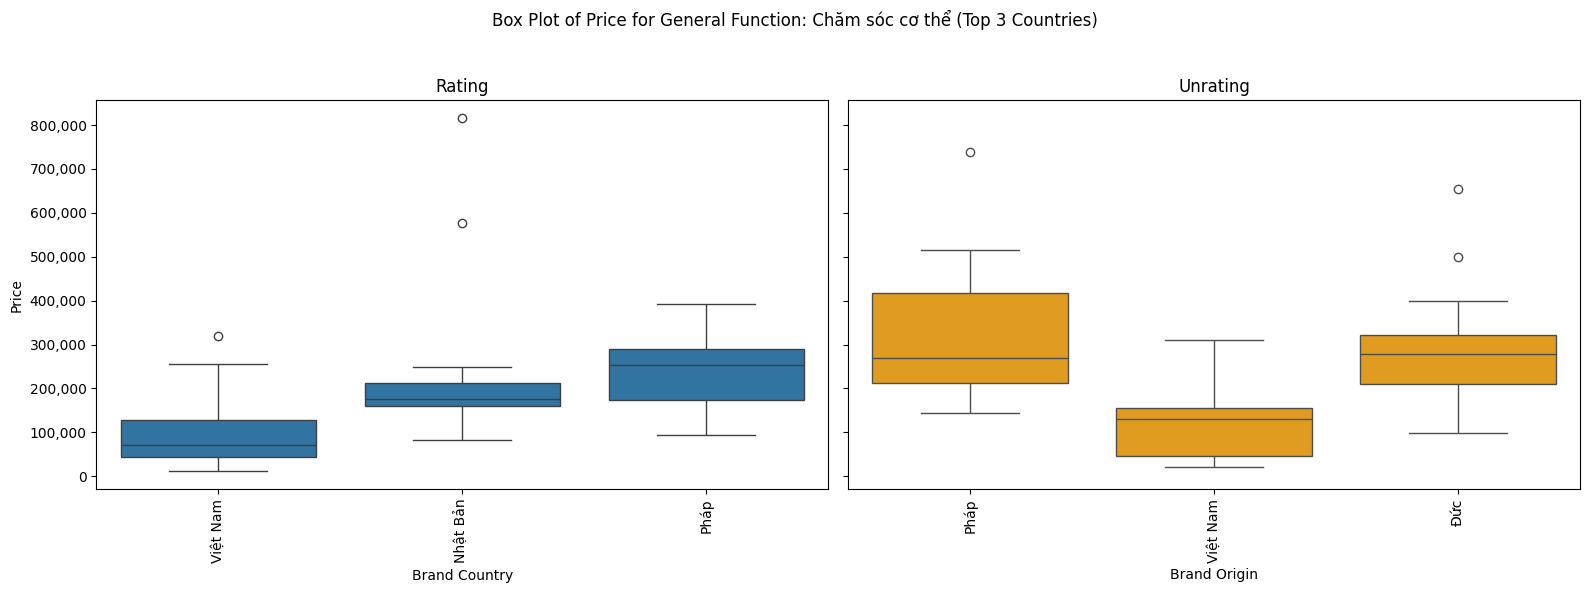

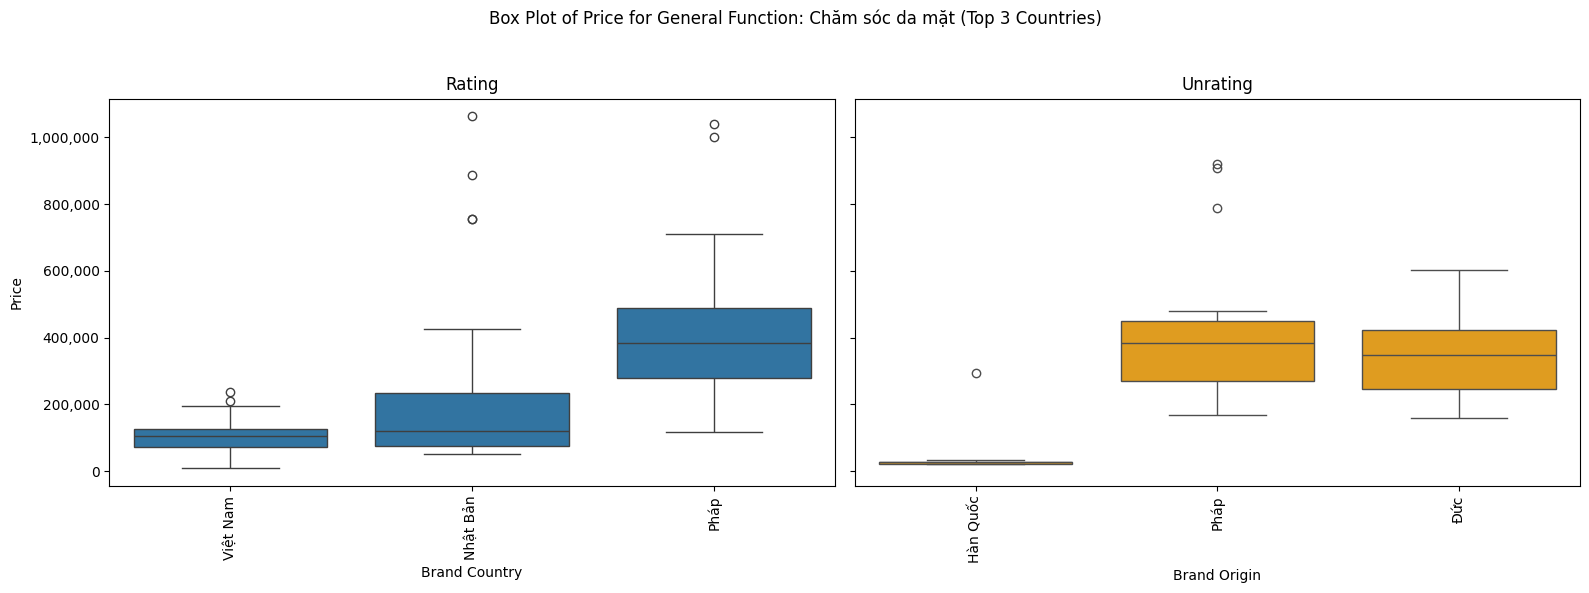

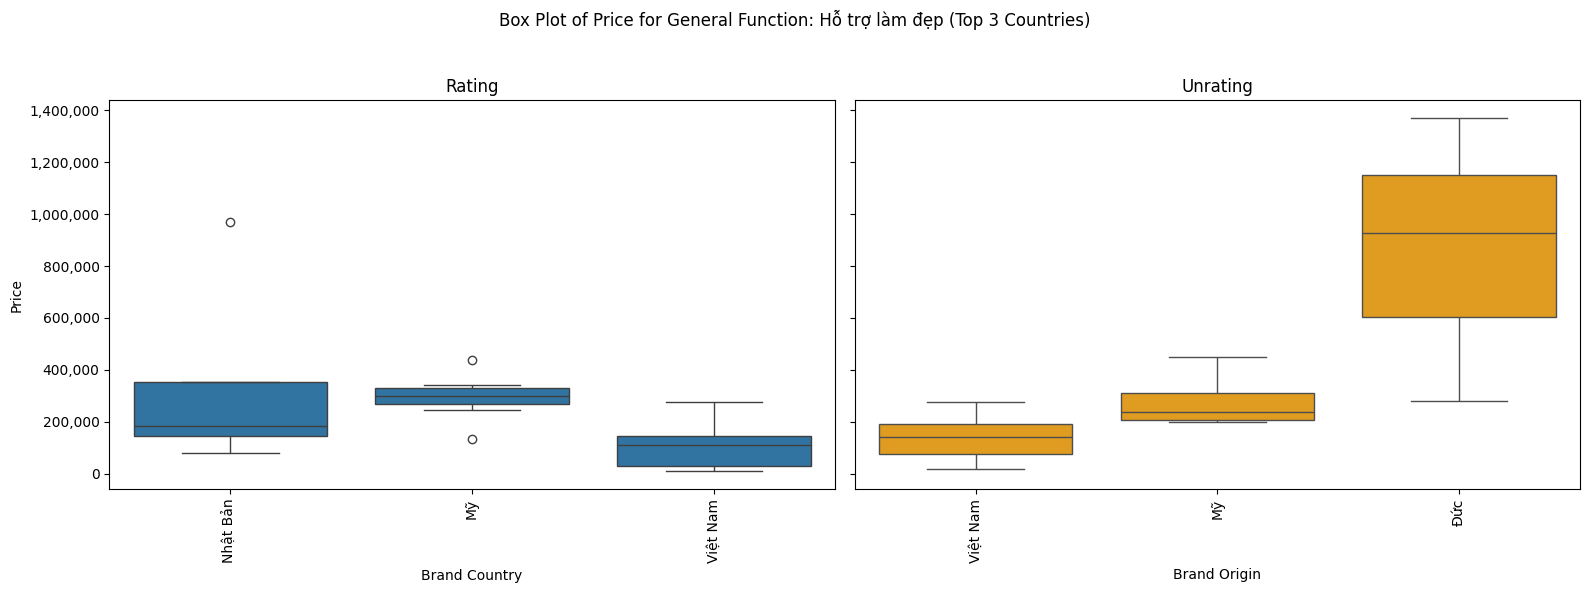

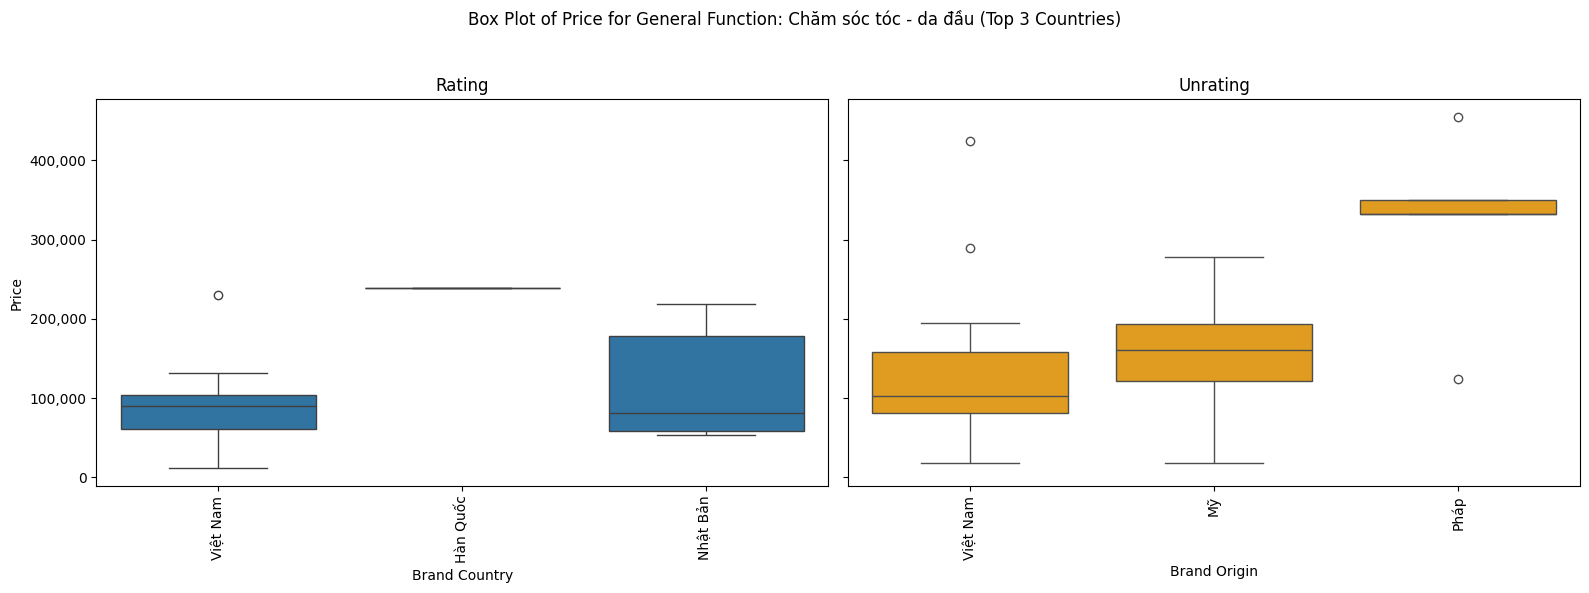

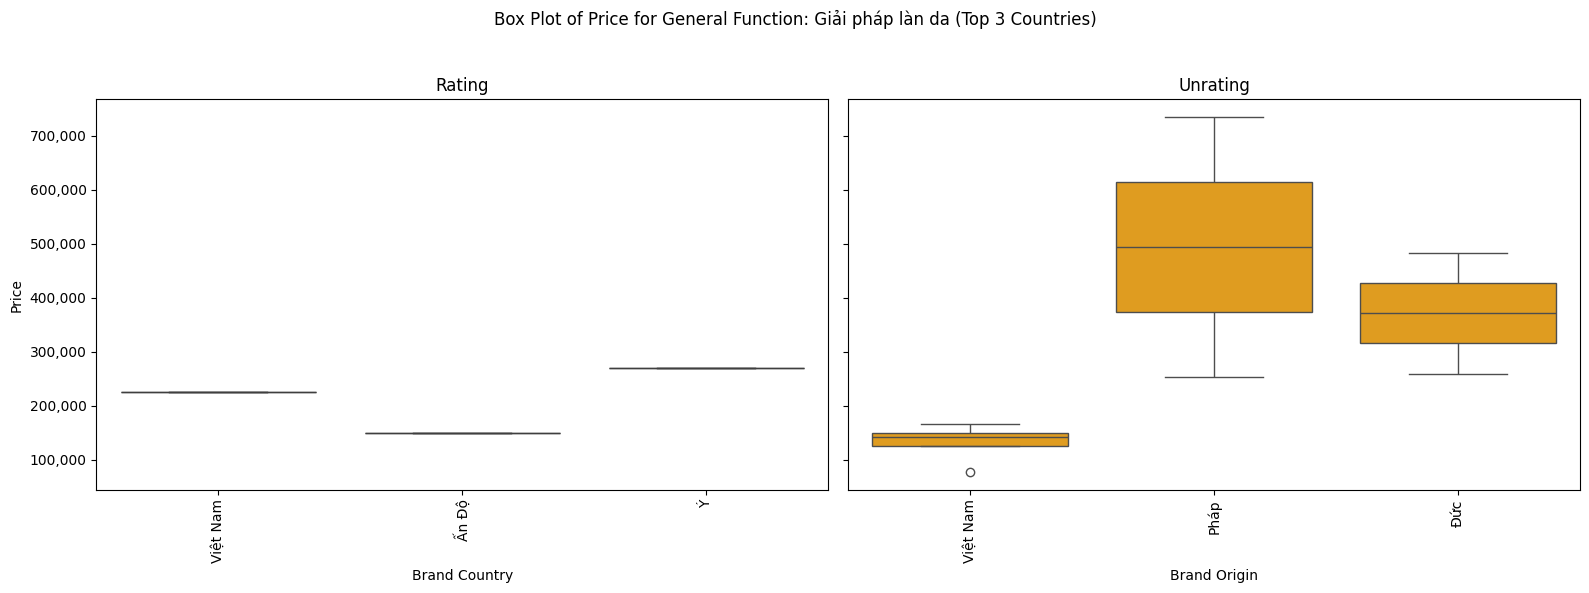

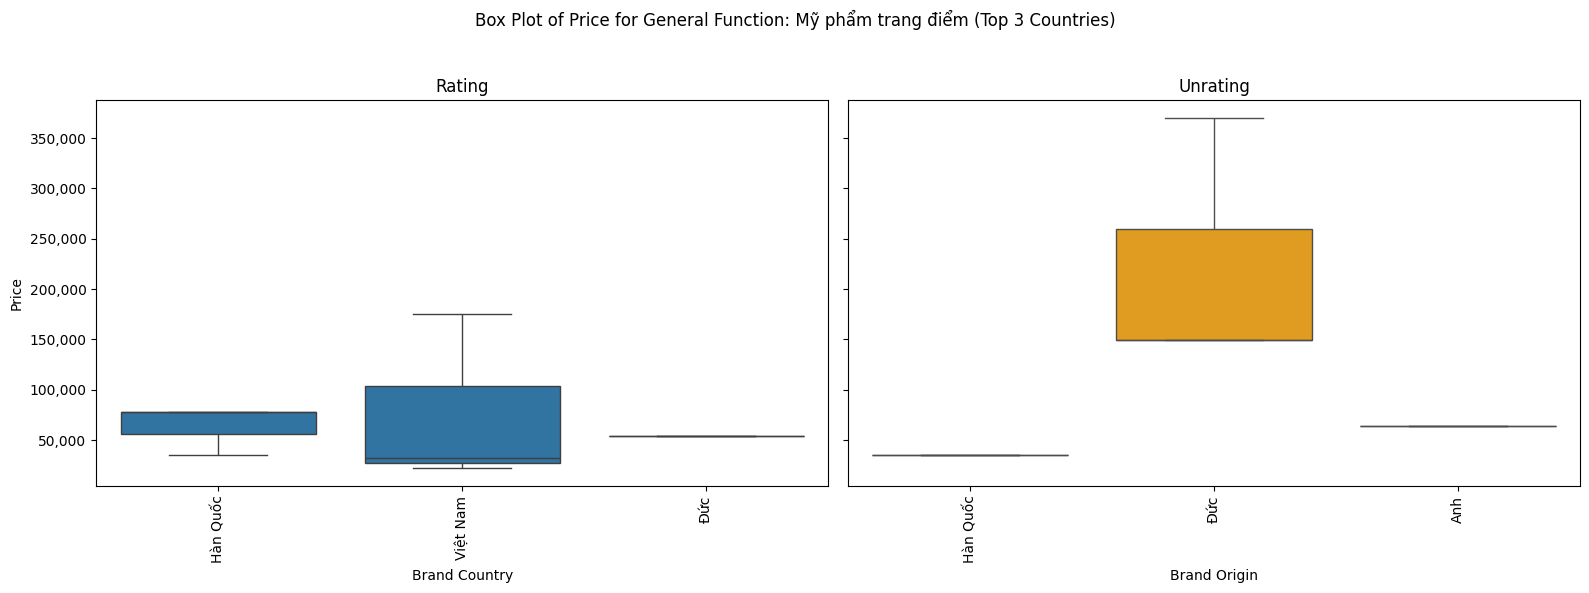

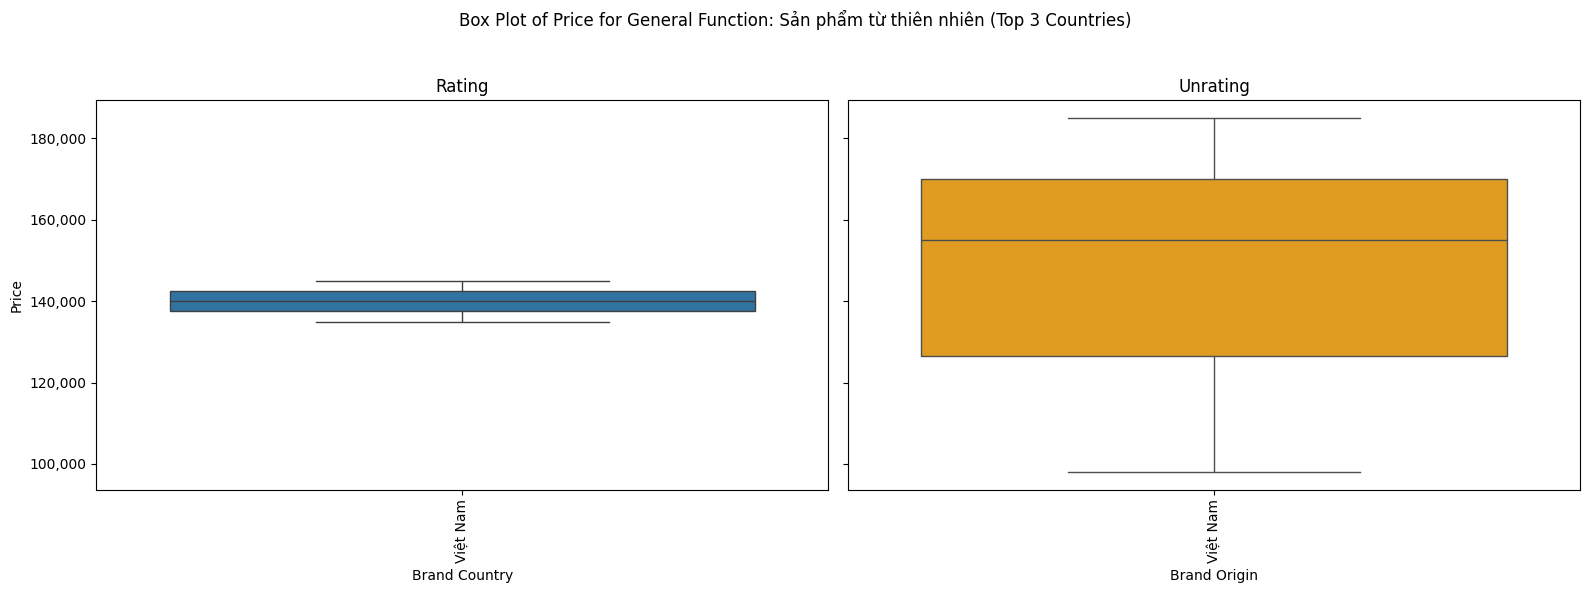

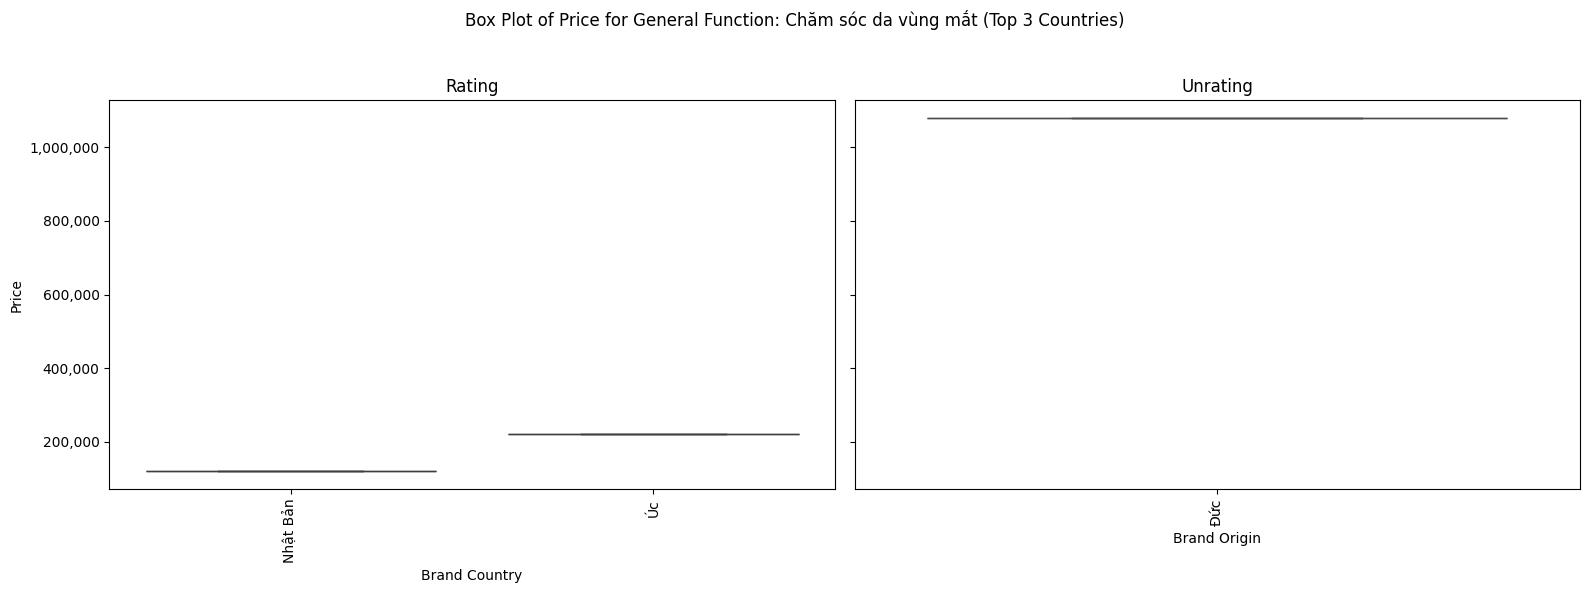

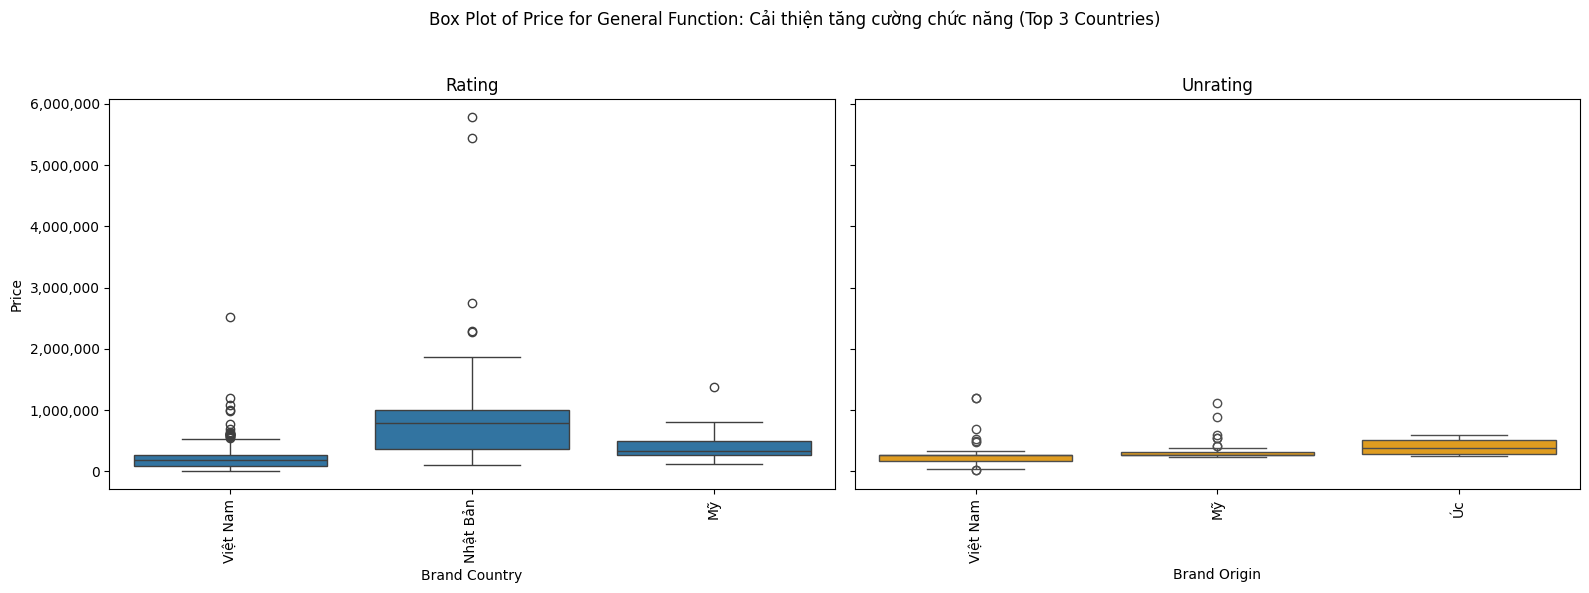

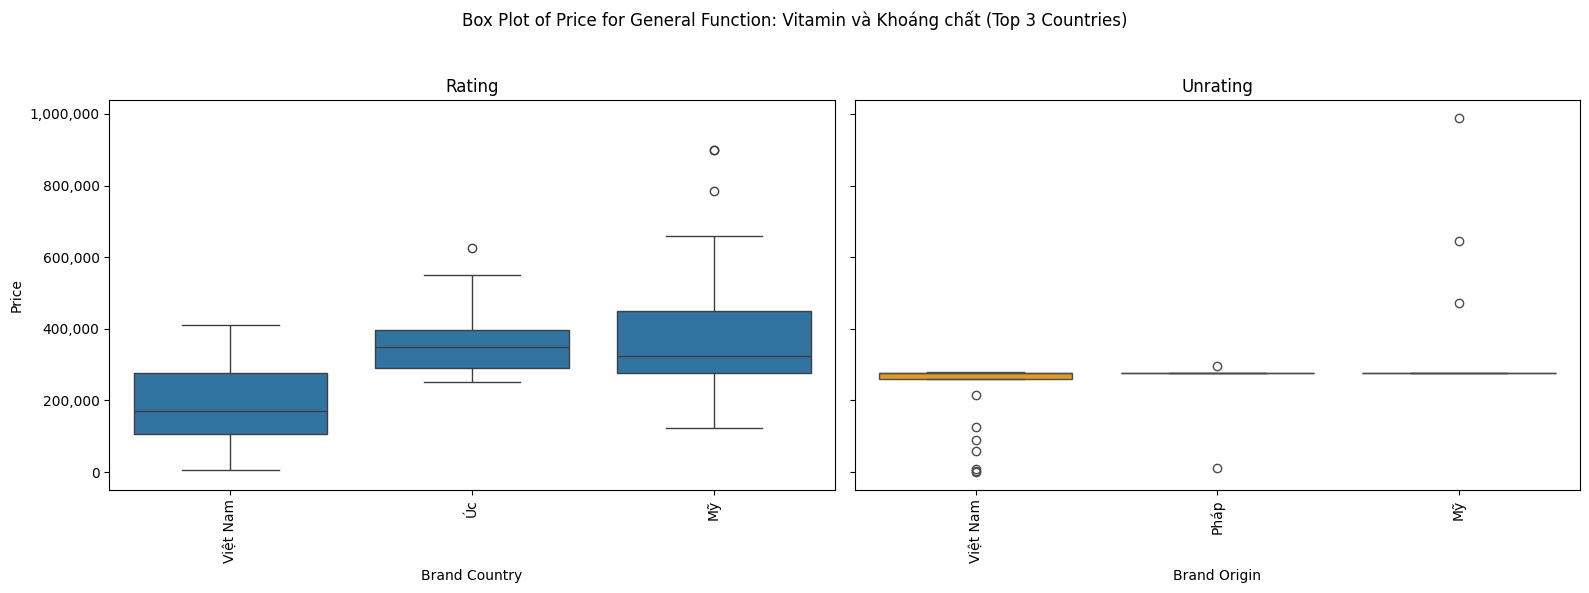

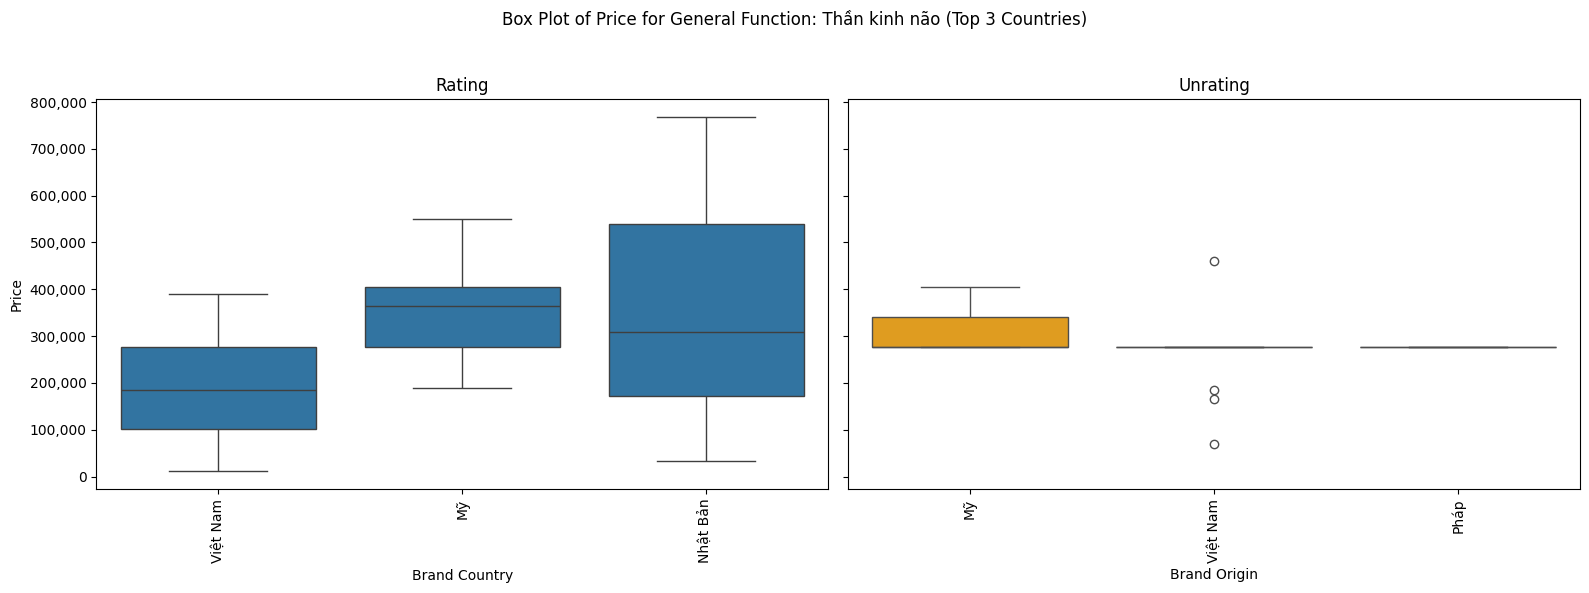

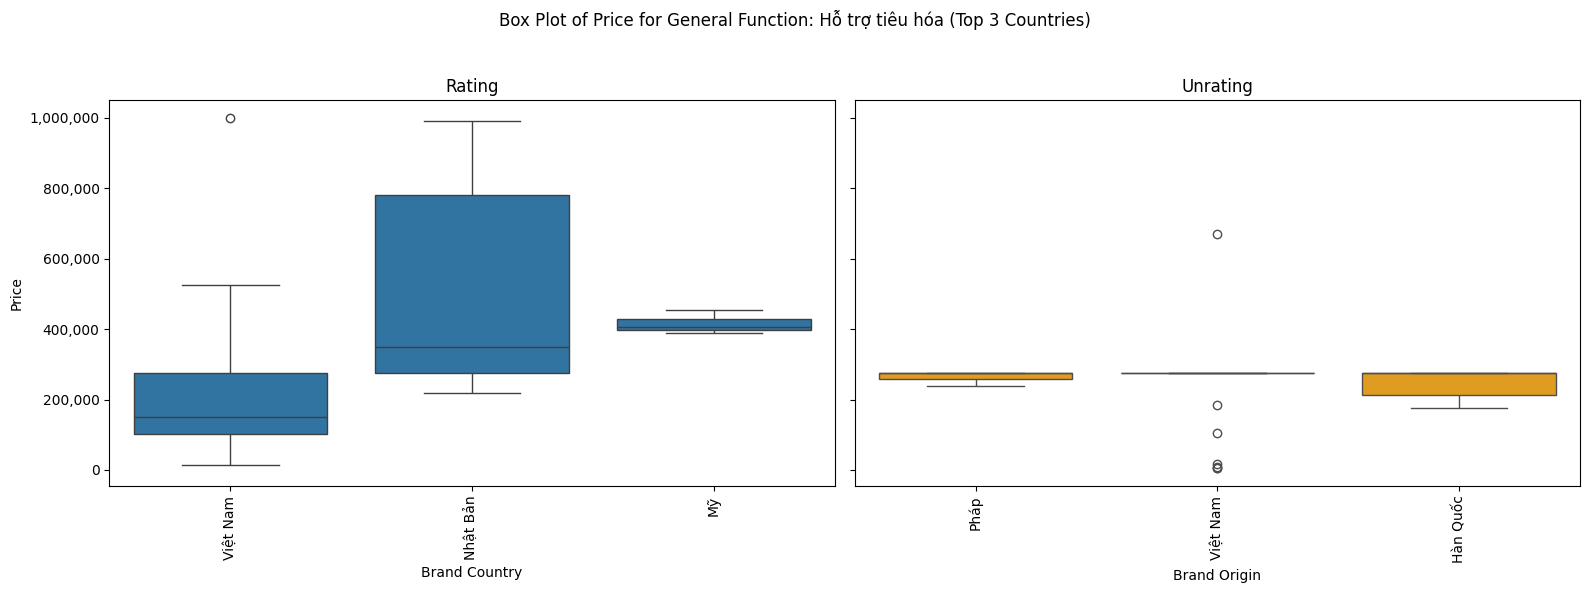

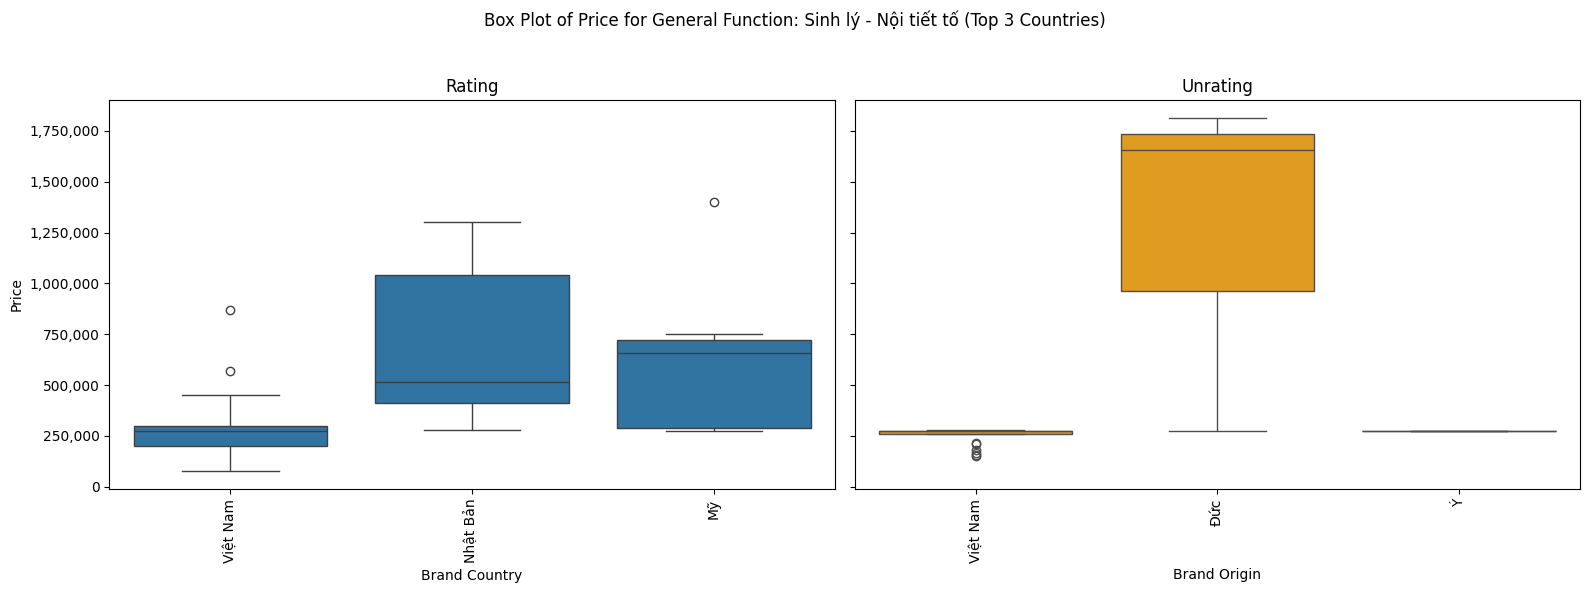

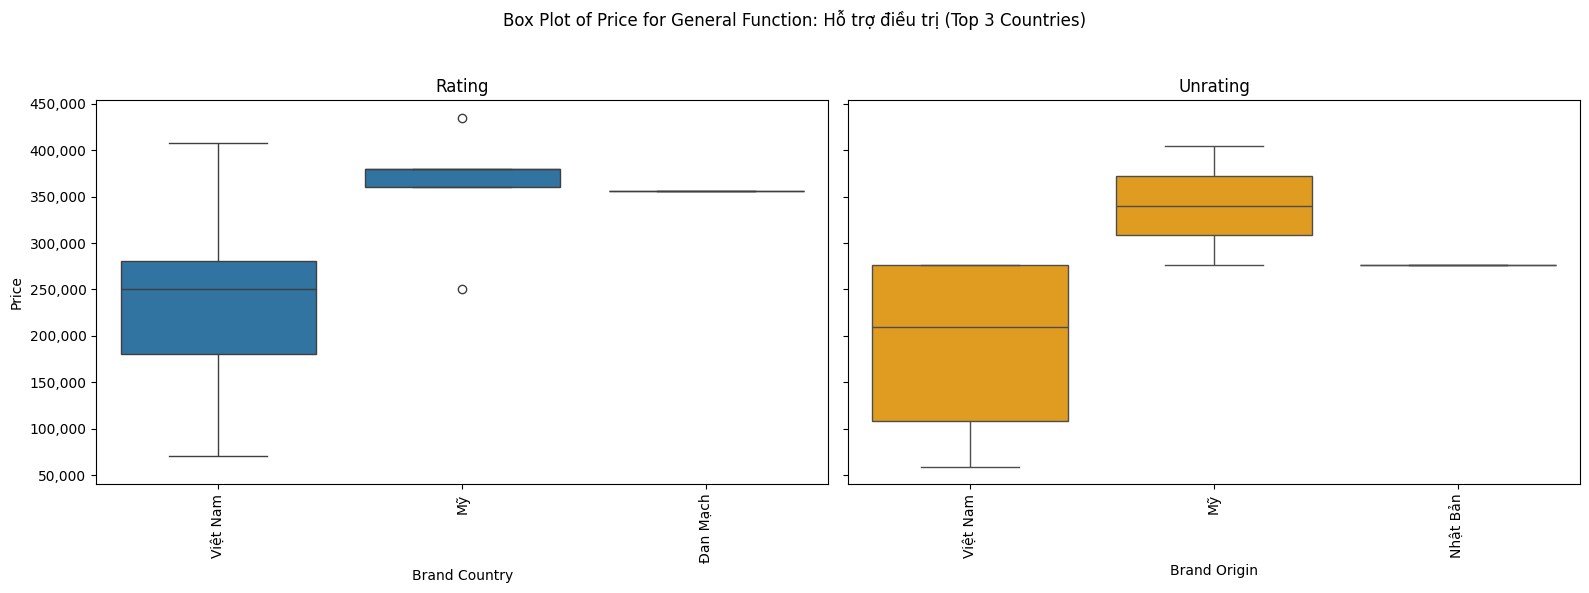

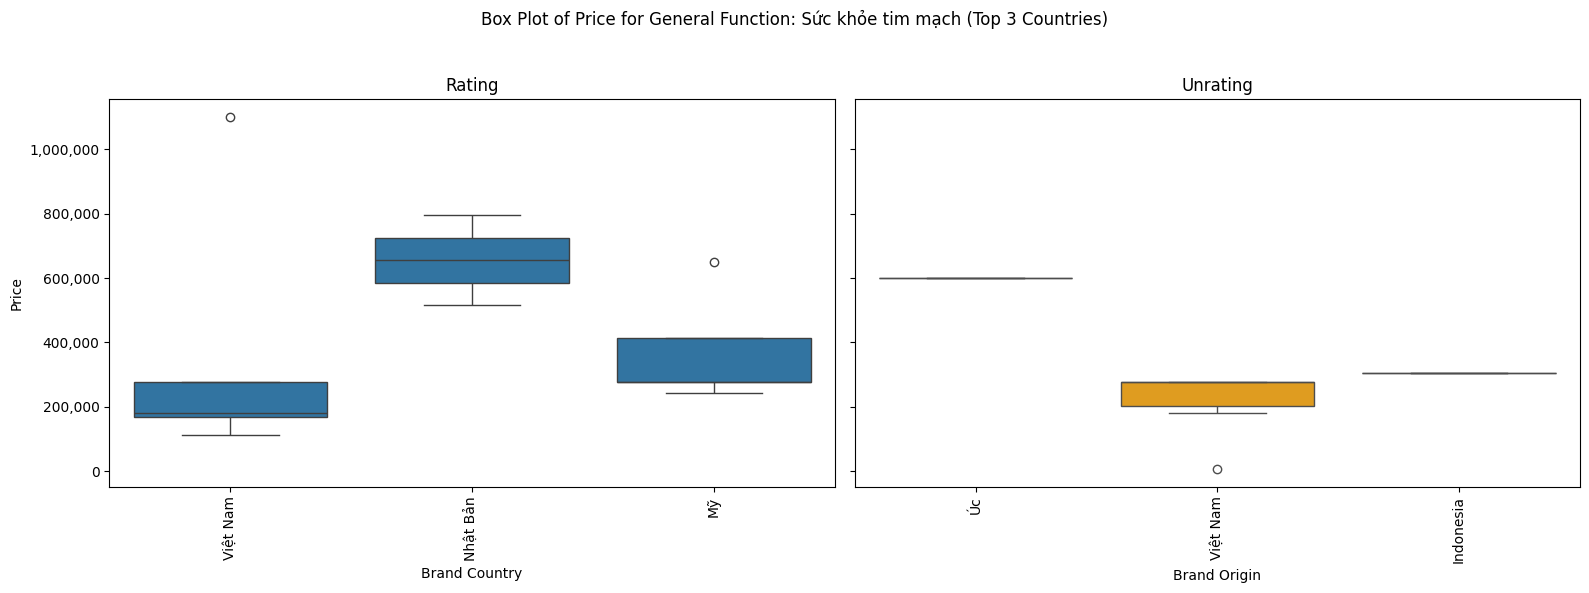

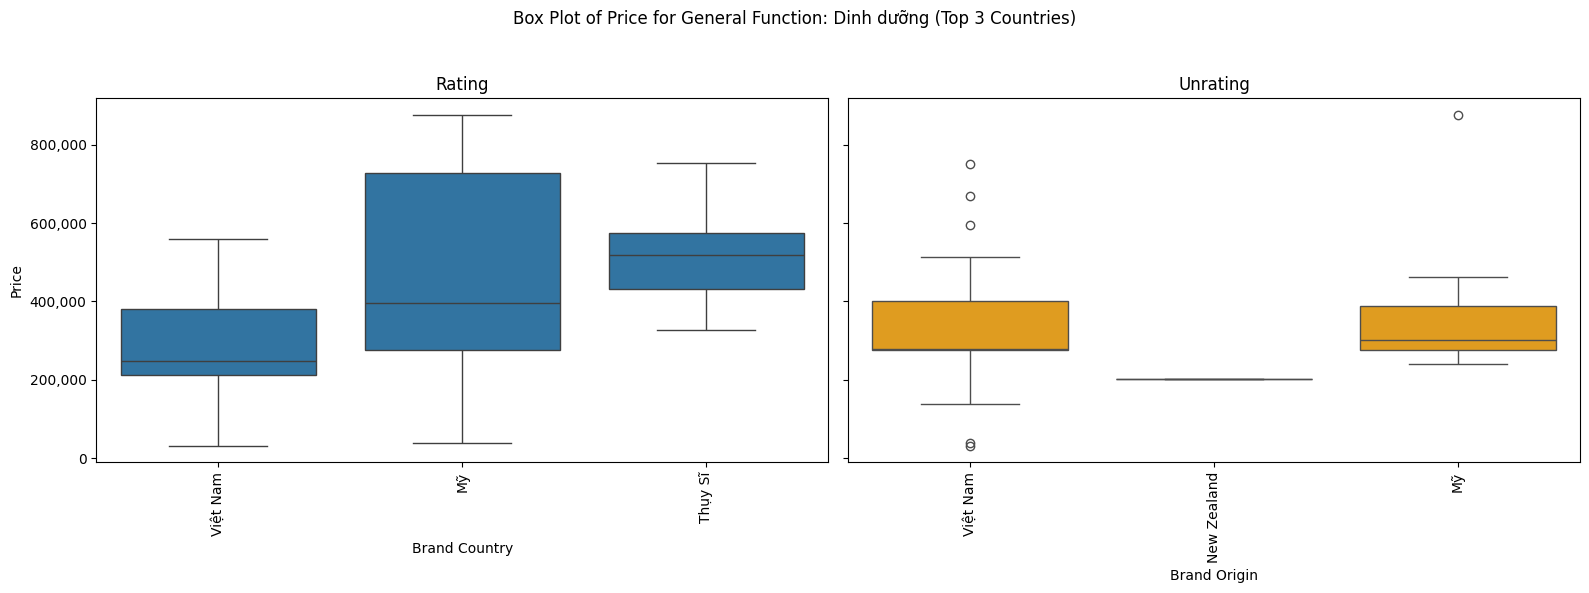

In [20]:
for func in unique_func:
    plot_price_boxplot_top3_countries(func)

- Ở hầu hết các mục chức năng, những sản phẩm không được quan tâm chủ yếu là do giá thành cao.

- Tuy nhiên, ở các mục chức năng như "Cải thiện tăng cường chức năng", "Vitamin và khoáng chất", "Thần kinh não", "Hỗ trợ tiêu hóa", "Sức khỏe tim mạch", "Dinh dưỡng" tuy có khoảng giá bán cao nhưng vẫn được quan tâm nhiều

- Sinh lý - Nội tiết tố: Sản phẩm được quan tâm có giá thành hâu như tương đối cao

==> Giá có thể ảnh hưởng đến nhu cầu người mua

In [21]:
def plot_top5_brands_stacked_bar(func: str, dataframe):
    # Lấy top 3 quốc gia xuất xứ cho chức năng cụ thể
    top_3_countries = top3_origin_countries_by_general_function(func, dataframe)
    
    func_df = dataframe[(dataframe['General_function'] == func) & (dataframe['Brand Origin'].isin(top_3_countries))]

    # Lấy top 5 thương hiệu của từng quốc gia trong top 3 quốc gia
    top5_brands_by_country = {}
    for country in top_3_countries:
        country_df = func_df[func_df['Brand Origin'] == country]
        top_5_brands = country_df['Trademark'].value_counts().nlargest(5).index.tolist()
        top5_brands_by_country[country] = top_5_brands

    # Tạo DataFrame đếm tần suất xuất hiện của top 5 thương hiệu cho từng quốc gia
    brand_counts = []
    for country, top_5_brands in top5_brands_by_country.items():
        for brand in top_5_brands:
            count = func_df[(func_df['Brand Origin'] == country) & (func_df['Trademark'] == brand)].shape[0]
            brand_counts.append({'Brand Origin': country, 'Trademark': brand, 'Count': count})
    
    brand_counts_df = pd.DataFrame(brand_counts)

    # Chuyển DataFrame thành dạng pivot để chuẩn bị cho biểu đồ chồng
    pivot_df = brand_counts_df.pivot(index='Brand Origin', columns='Trademark', values='Count').fillna(0)

    # Tính tỷ lệ phần trăm cho mỗi thương hiệu trong mỗi quốc gia
    pivot_percentage_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

    plt.figure(figsize=(12, 8))

    # Vẽ biểu đồ cột chồng 100%
    ax = pivot_percentage_df.plot(kind='bar', stacked=True, figsize=(12, 8), width=0.8)
    plt.title(f"Top 5 Brands Frequency in Top 3 Countries for General Function: {func} (100% Stacked)")
    plt.xlabel("Brand Origin")
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=45)
    plt.ylim(0, 100)

    plt.legend(title="Brand", bbox_to_anchor=(1.2, 1), loc='upper right', borderaxespad=0.)

    plt.tight_layout()
    plt.show()




<Figure size 1200x800 with 0 Axes>

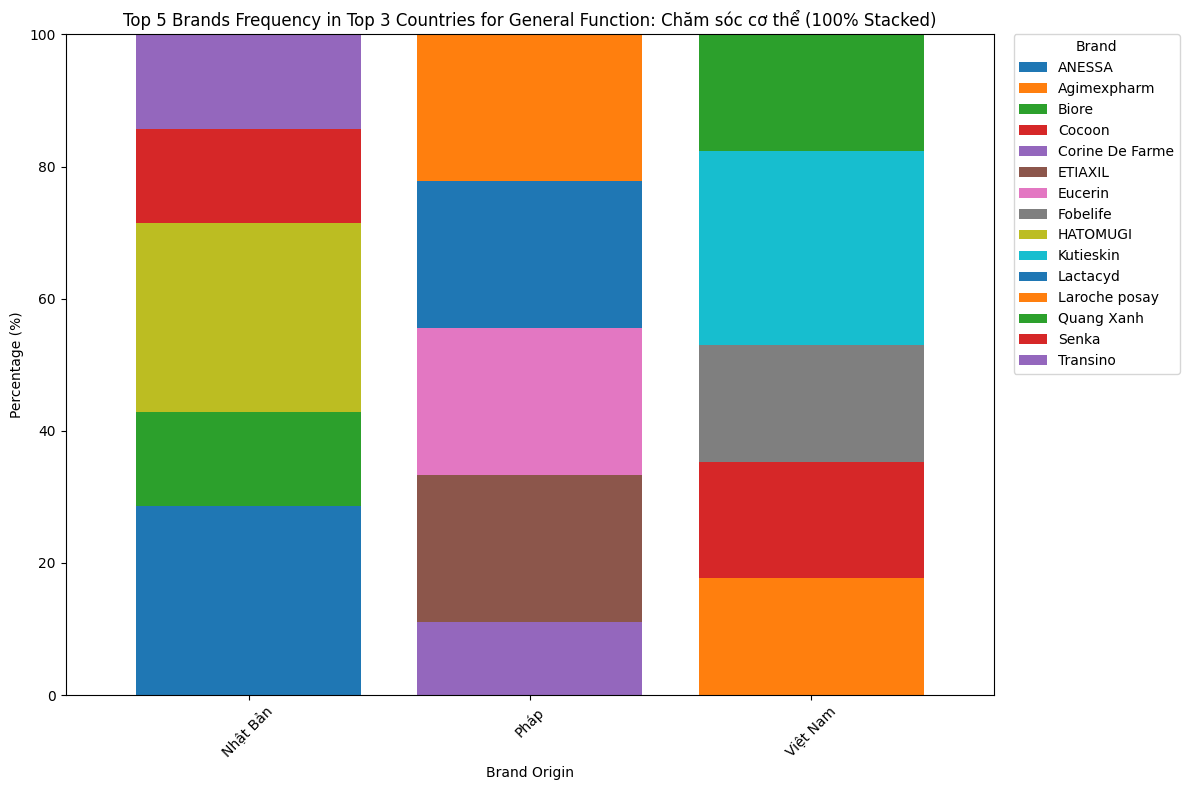

<Figure size 1200x800 with 0 Axes>

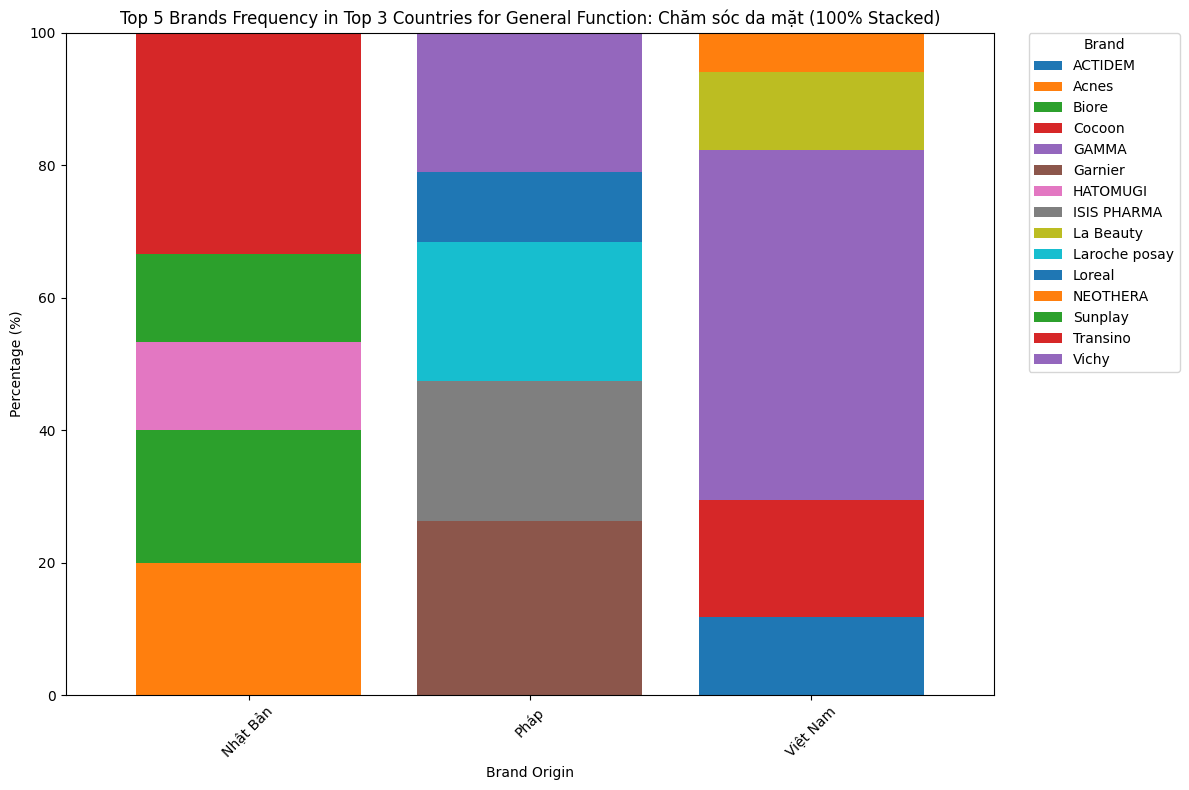

<Figure size 1200x800 with 0 Axes>

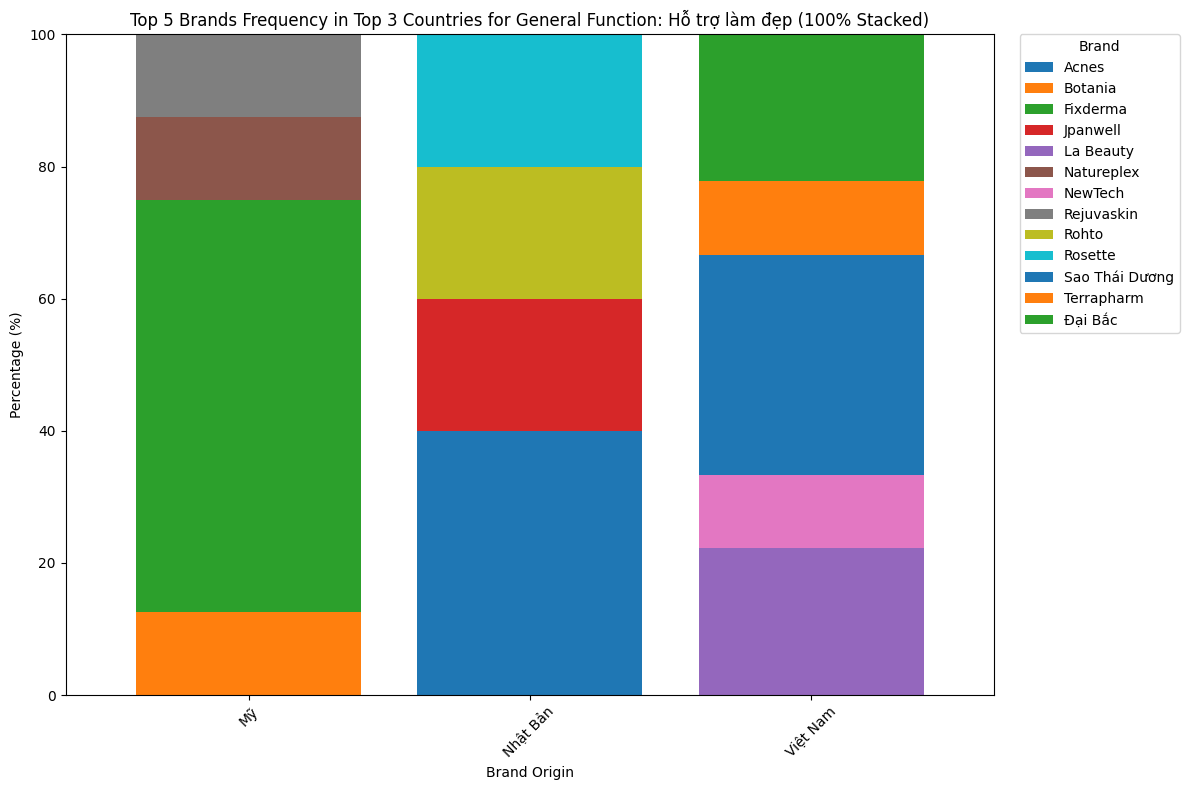

<Figure size 1200x800 with 0 Axes>

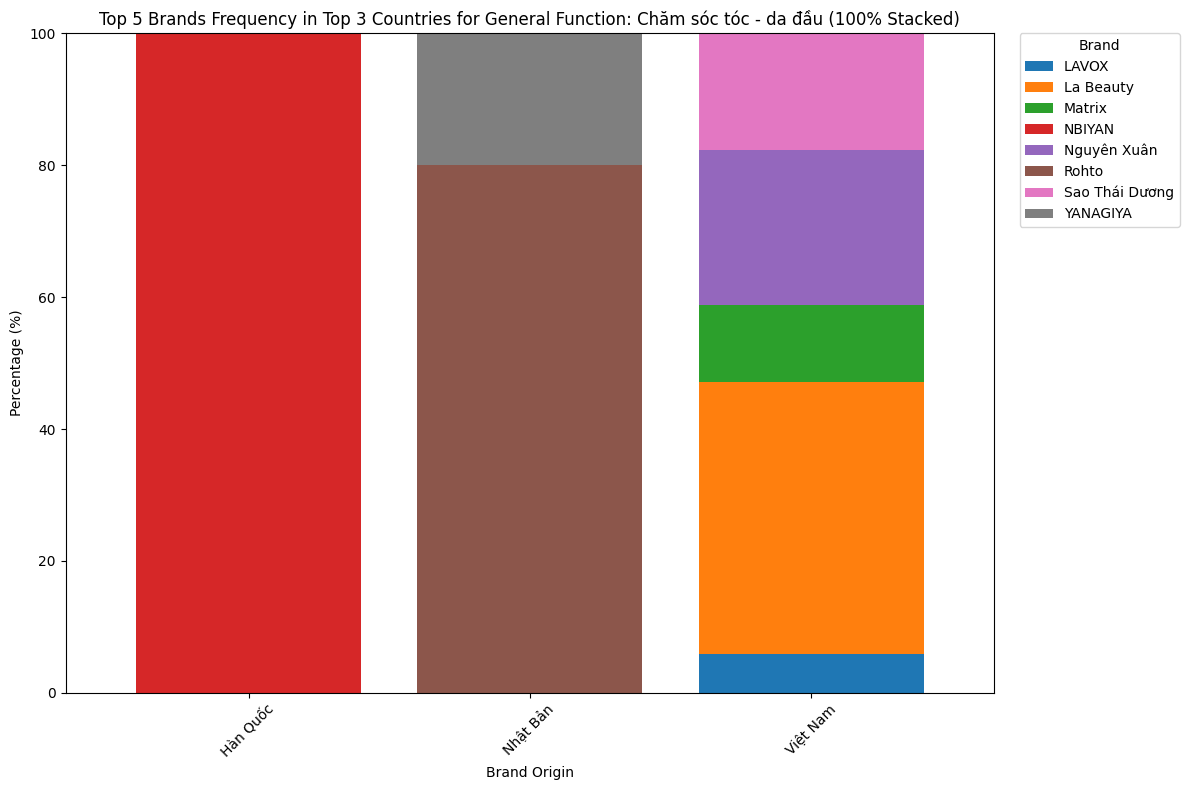

<Figure size 1200x800 with 0 Axes>

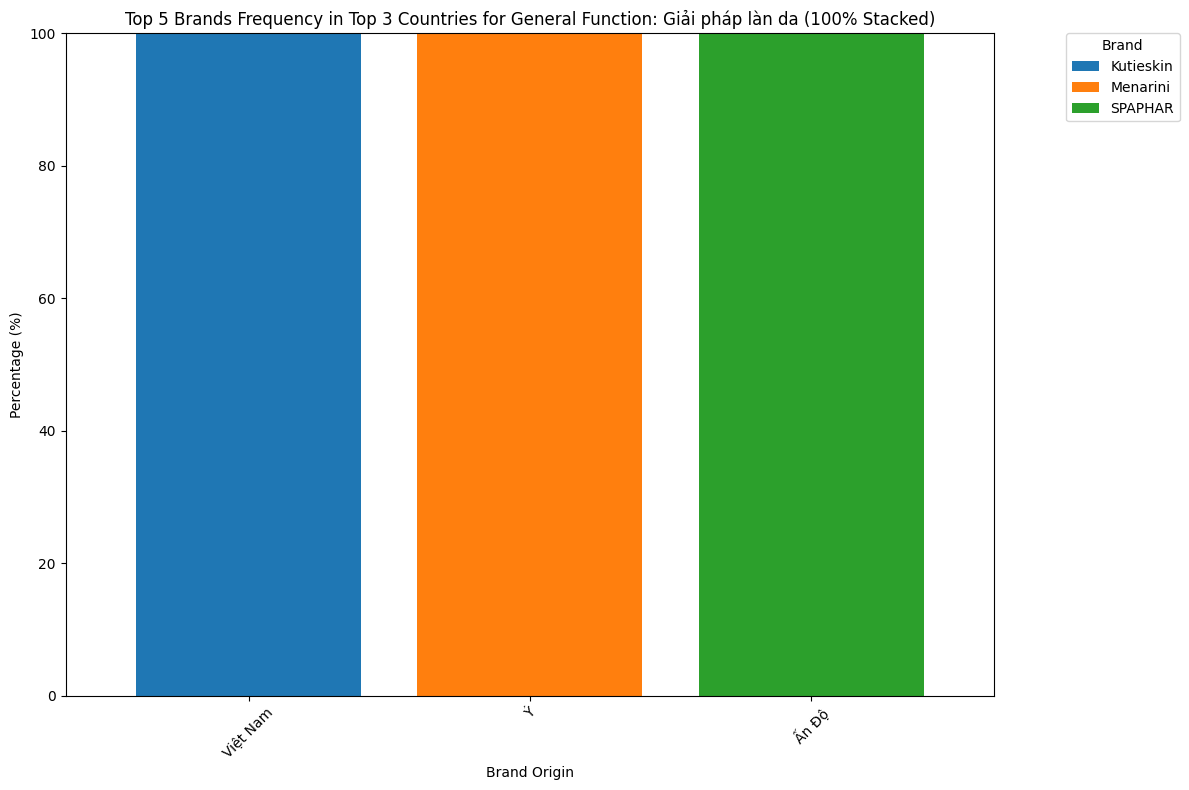

<Figure size 1200x800 with 0 Axes>

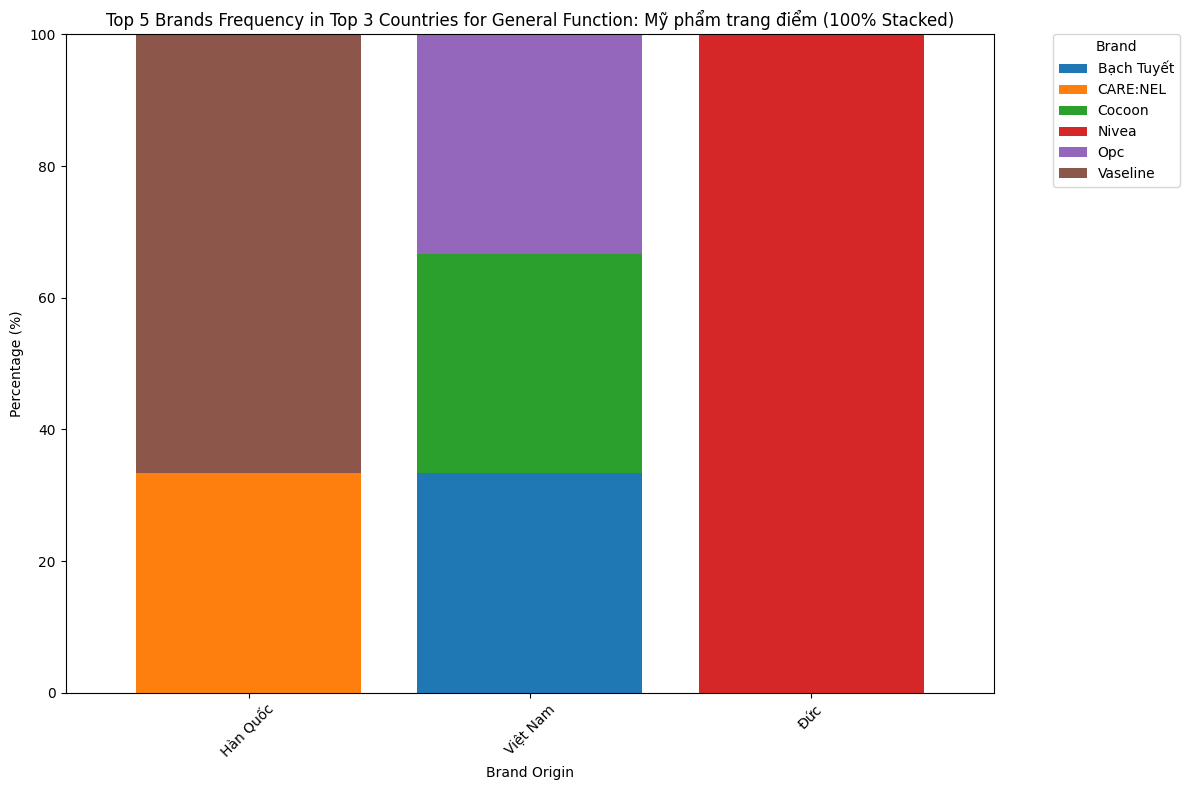

<Figure size 1200x800 with 0 Axes>

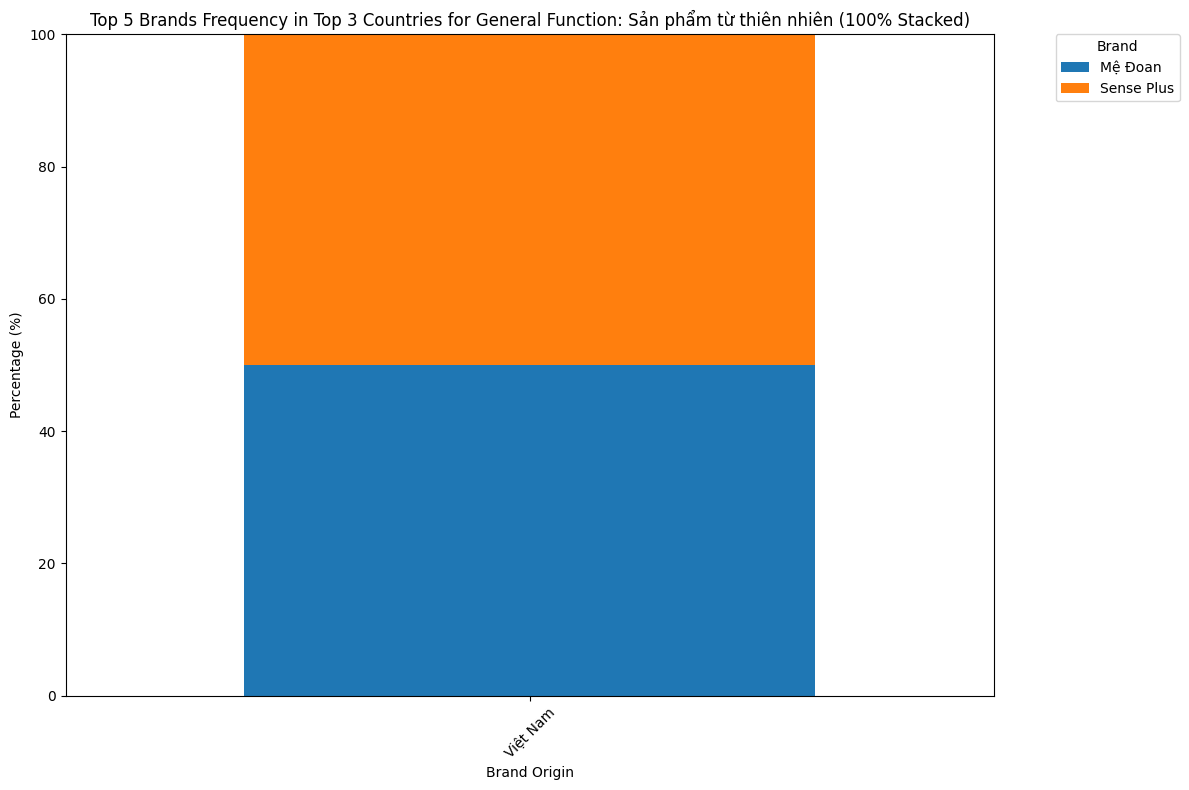

<Figure size 1200x800 with 0 Axes>

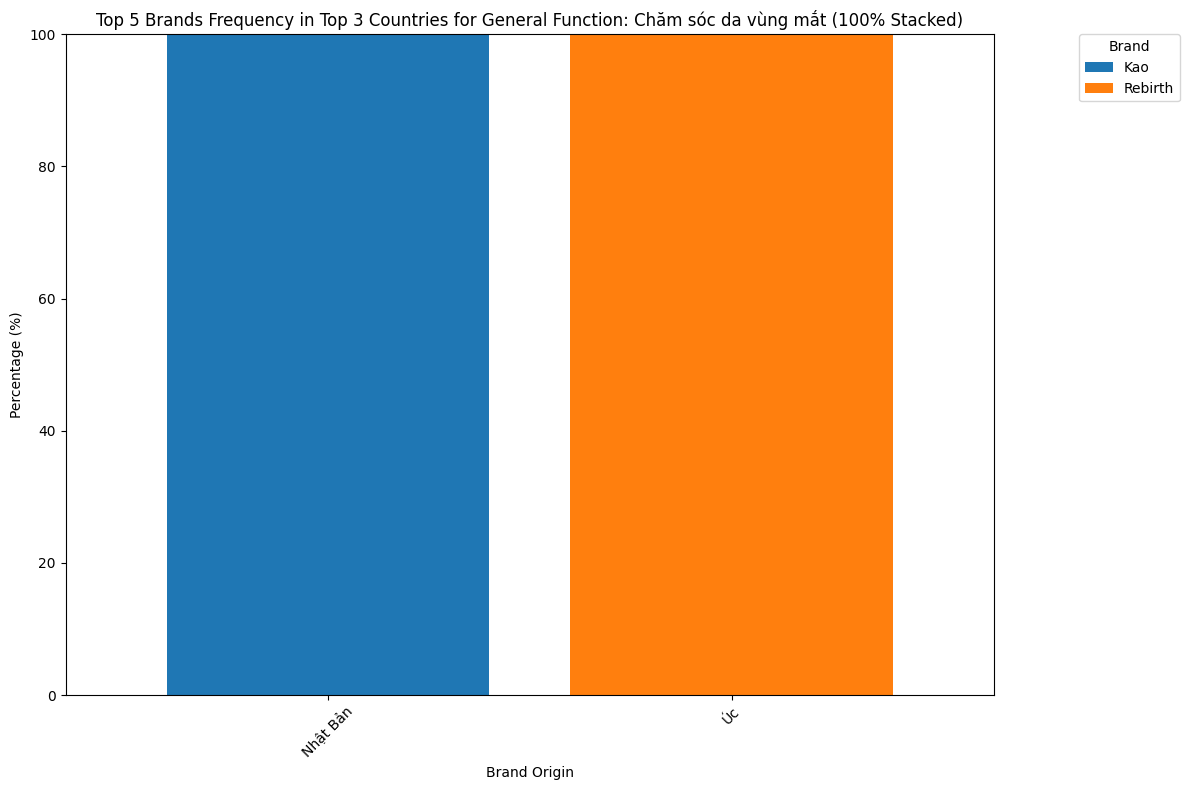

<Figure size 1200x800 with 0 Axes>

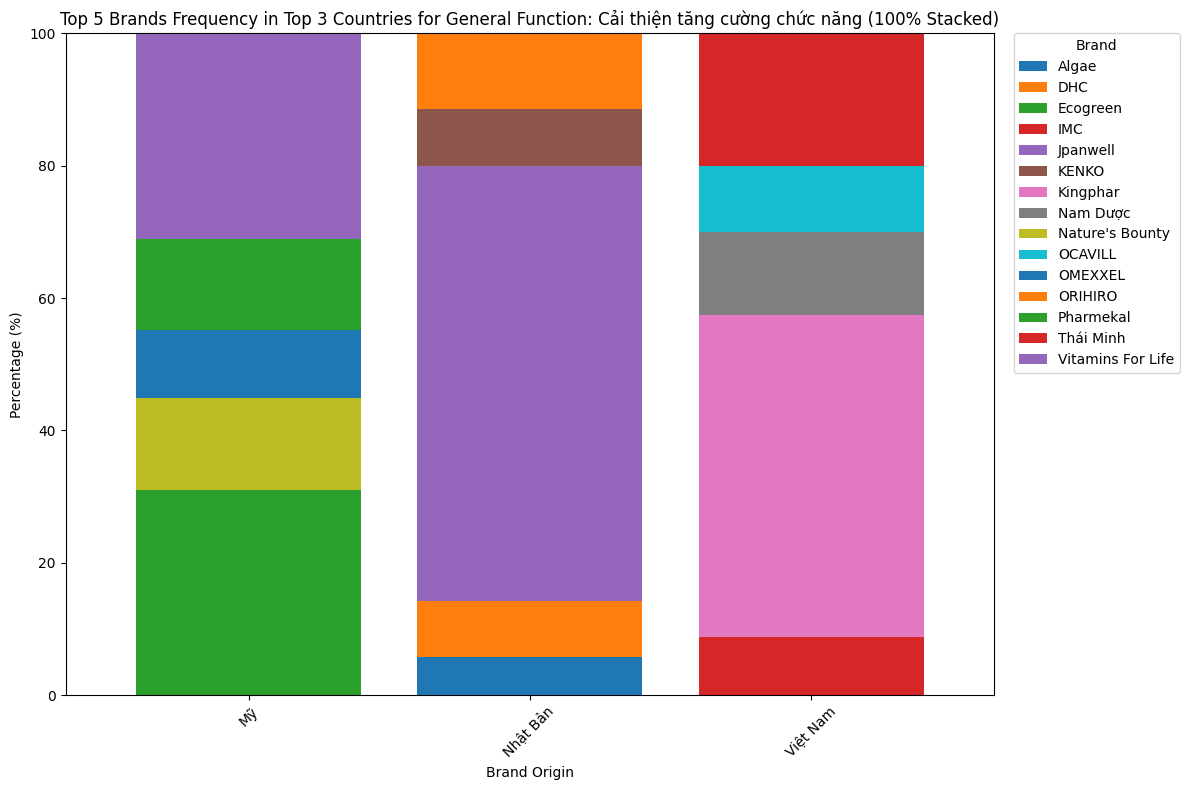

<Figure size 1200x800 with 0 Axes>

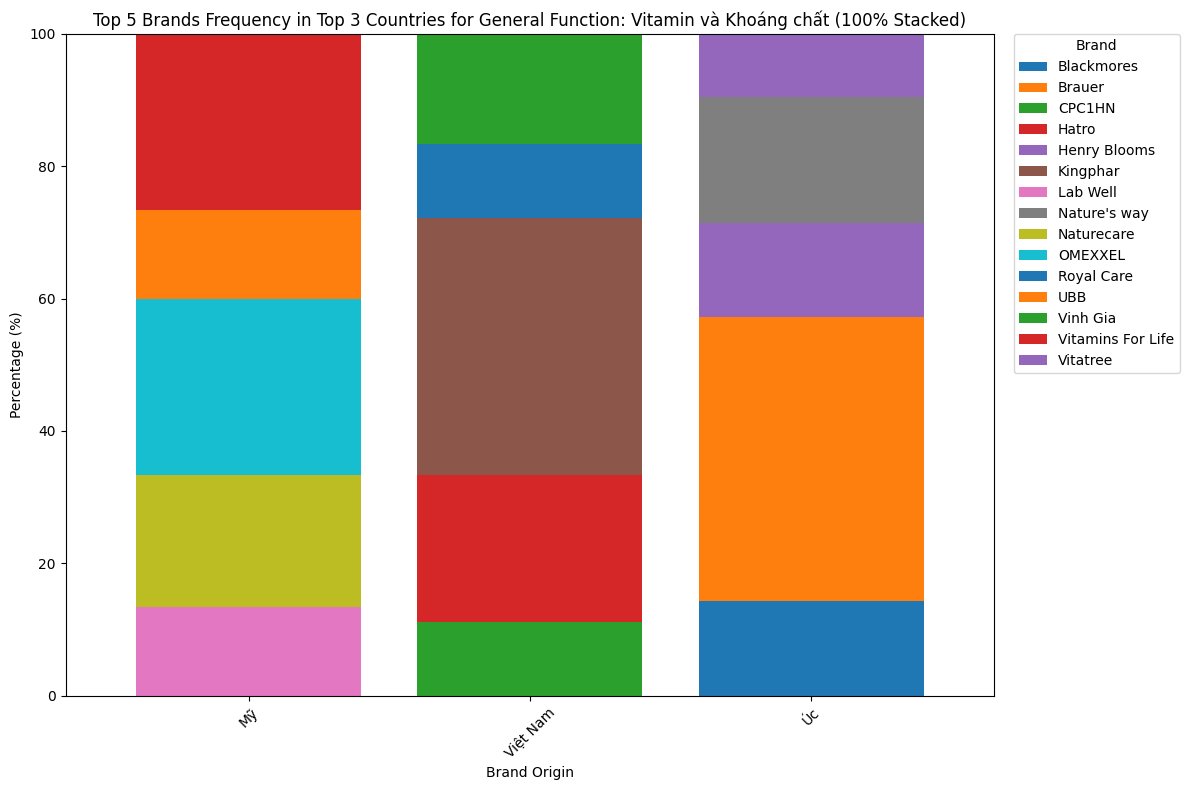

<Figure size 1200x800 with 0 Axes>

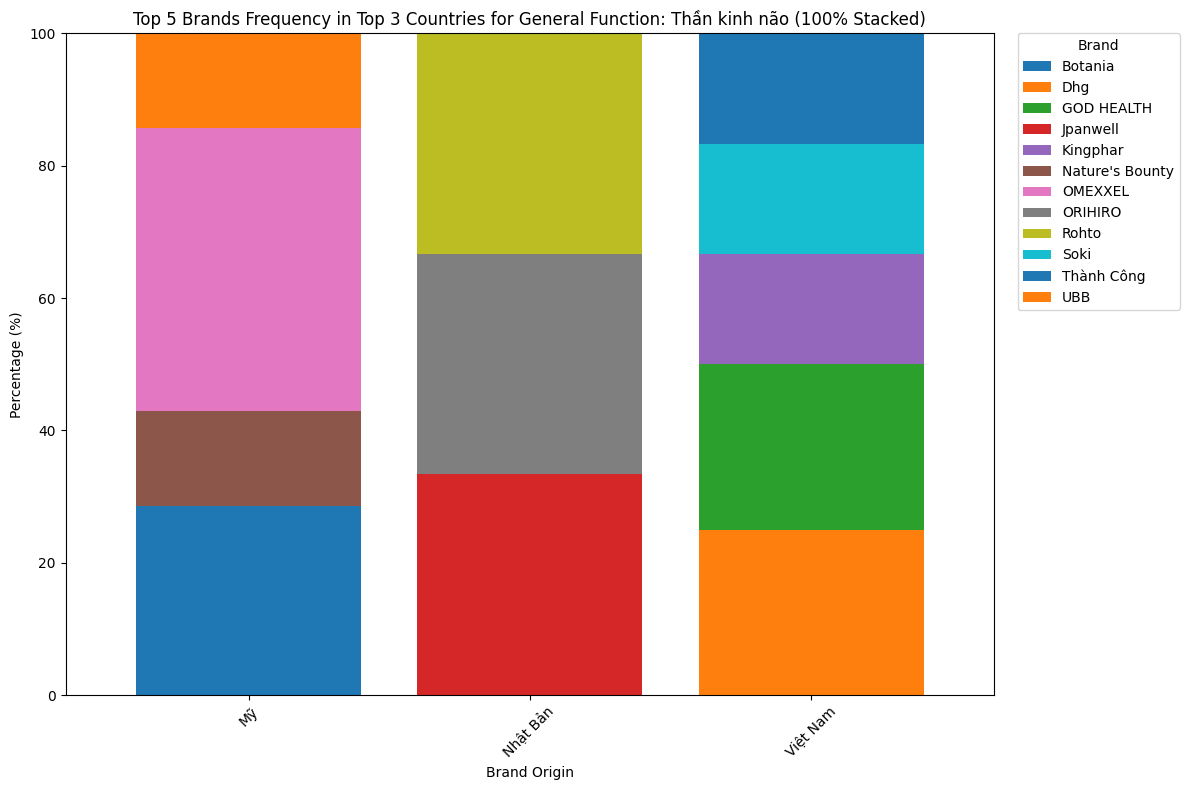

<Figure size 1200x800 with 0 Axes>

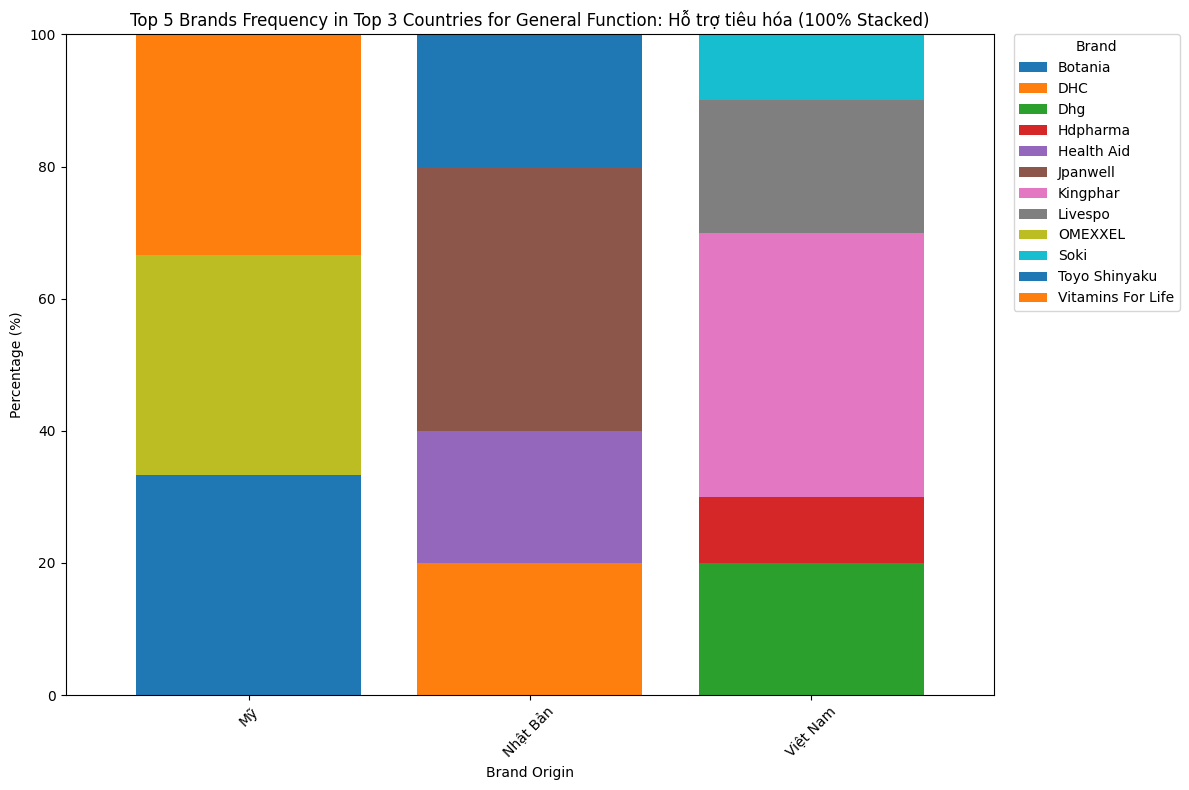

<Figure size 1200x800 with 0 Axes>

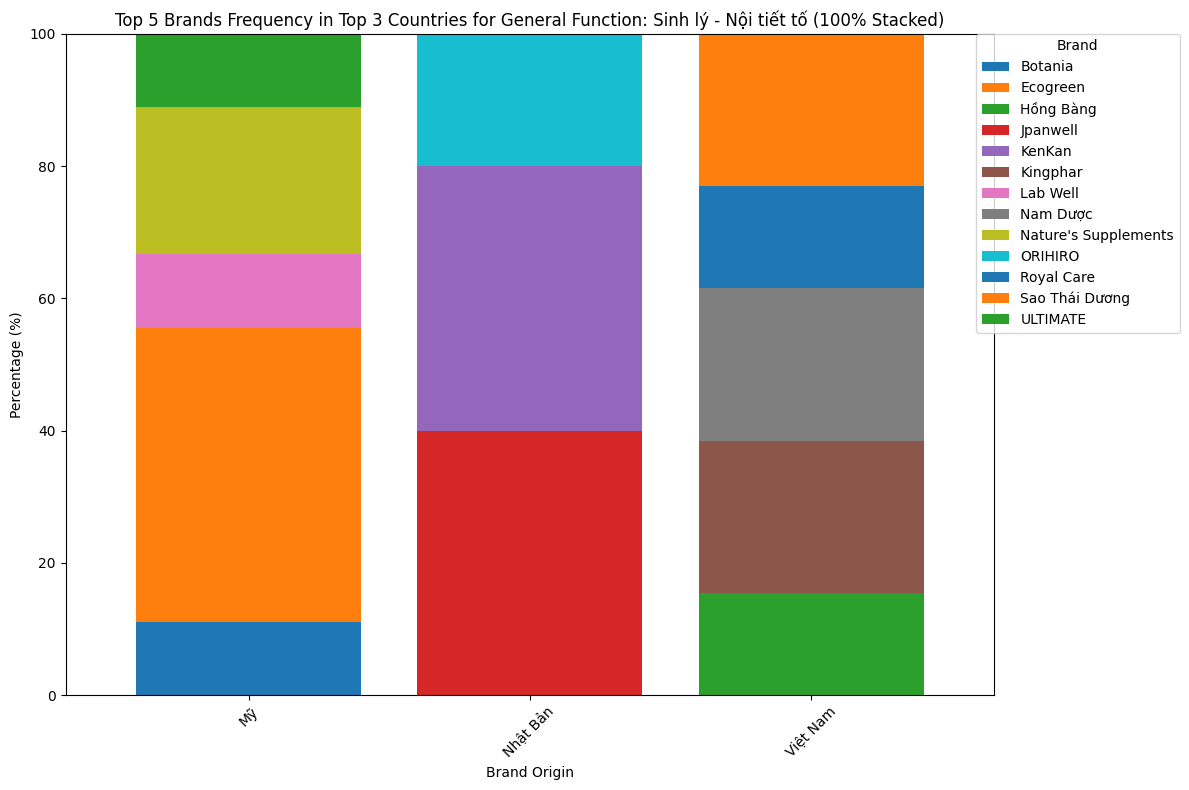

<Figure size 1200x800 with 0 Axes>

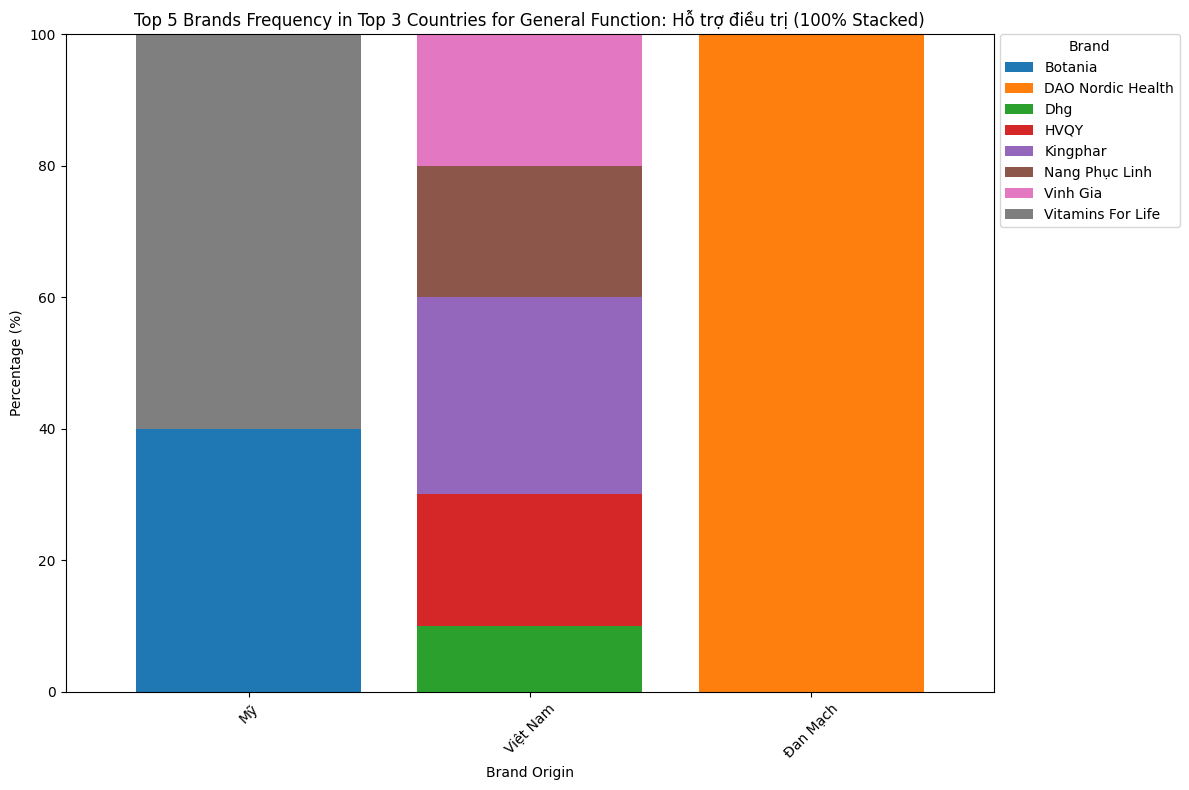

<Figure size 1200x800 with 0 Axes>

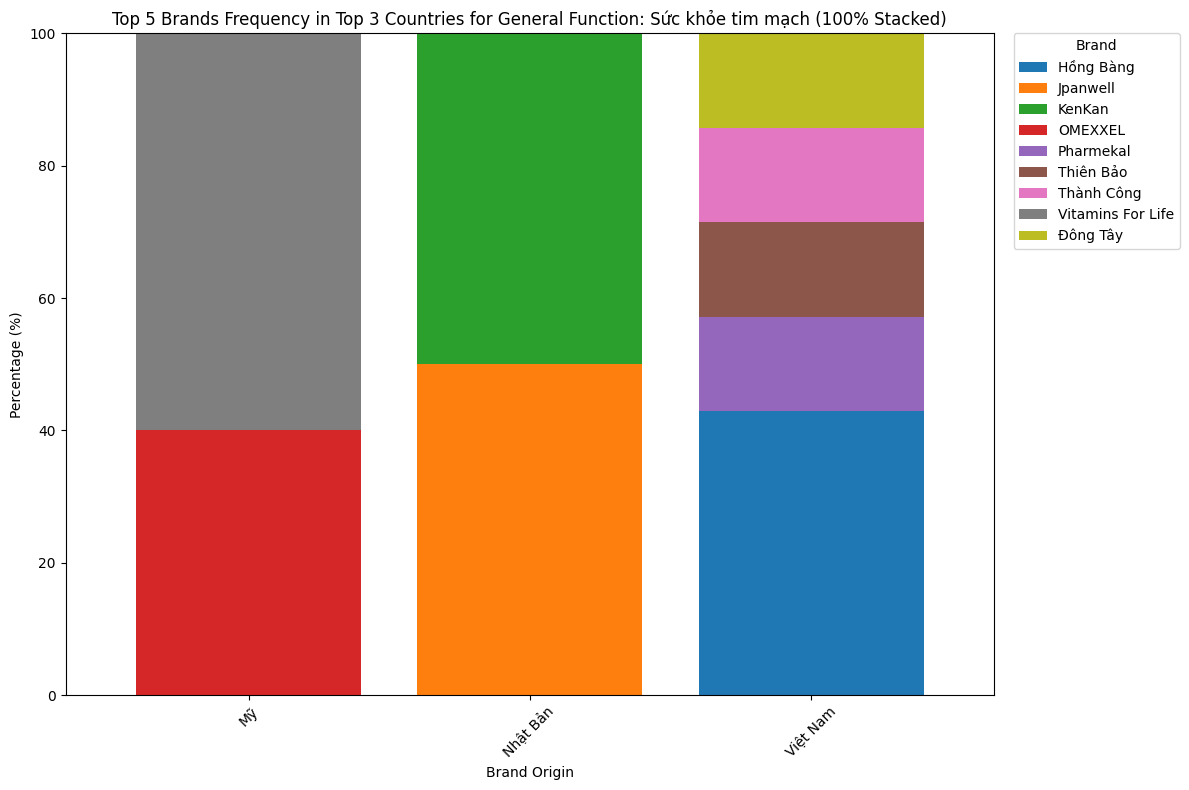

<Figure size 1200x800 with 0 Axes>

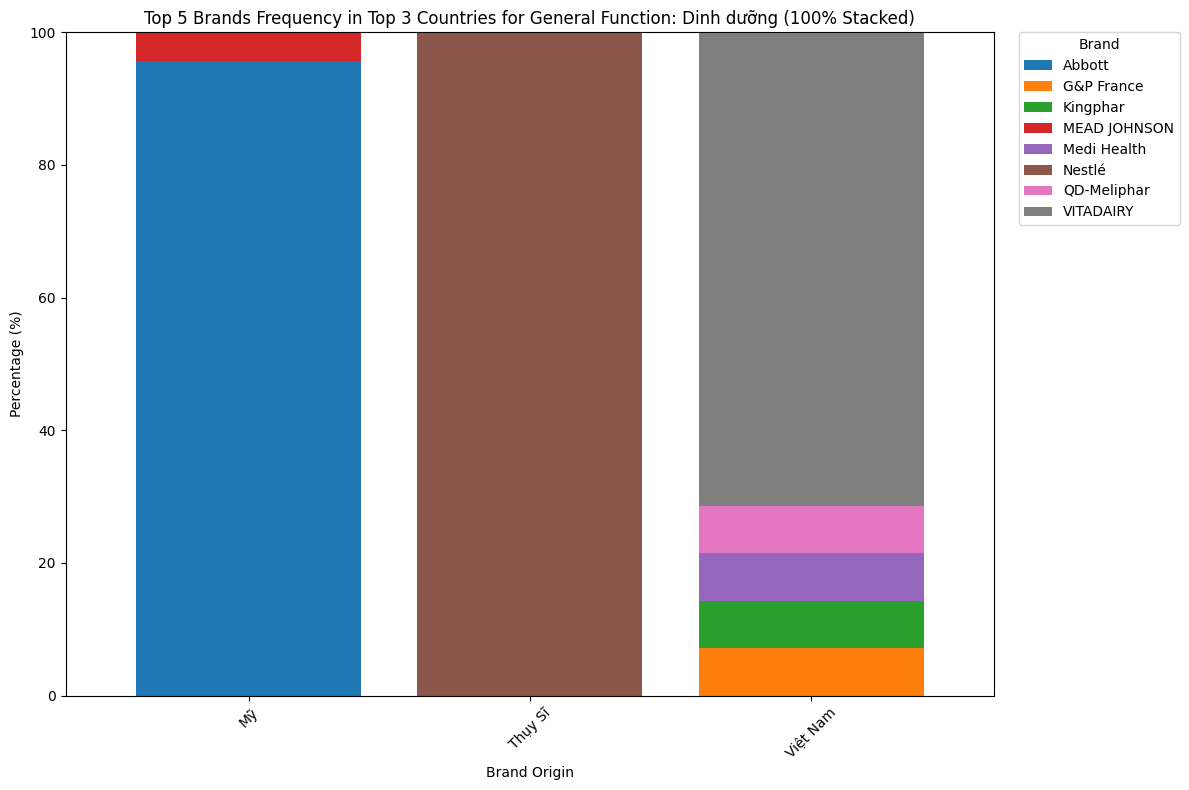

In [22]:
for func in unique_func:
    plot_top5_brands_stacked_bar(func, rating_df)

1. Chọn ra 3 quốc giá xuất xứ phổ tiếng nhất ở các mục chức năng, để kiểm tra xem thương hiệu có ảnh hưởng tới sự phổ biến đó không?

- Phần trăm (%) tần suất xuất hiện của một số thương hiệu của các quốc gia xuất xứ chiếm phần lớn tỉ trọng

==> Thương hiệu ảnh hương đến nhu cầu, quyết định người mua